# S-JEPA Pretraining with Braindecode Backbone

Custom self-supervised pretraining notebook for S-JEPA-style masked latent prediction.

This notebook intentionally reuses the **engineering style** of
`lee2019_ssvep_finetune_sjepa_prelocal.ipynb` for:

- setup
- configuration
- artifact logging
- reproducibility
- validation

But this notebook is **not** a downstream classifier notebook.

It is the starter notebook for building a custom pretraining pipeline around:

- Braindecode `SignalJEPA` backbone components
- random spatial block masking
- teacher / student routing
- masked-token prediction
- EMA teacher updates

Sections 1 and 2 are scaffolded here. Continue implementation from Section 3 onward
by following the Copilot instructions and stories files.

# 1. Setup

## 1.1. Import Libraries

In [1]:
import sys
from pathlib import Path
import platform
import json
import hashlib
from datetime import datetime
import builtins
import random
import gc
from copy import deepcopy

import mne
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from braindecode.models import SignalJEPA
from braindecode.datasets import MOABBDataset
from braindecode.datasets.base import BaseConcatDataset
from braindecode.preprocessing import Preprocessor, preprocess
from braindecode.preprocessing.windowers import create_fixed_length_windows

from moabb.datasets import Lee2019_MI, Lee2019_ERP, Lee2019_SSVEP

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

print("Imports loaded successfully.")

Imports loaded successfully.


## 1.2. Runtime & Path Validation

In [2]:
print("Runtime Environment:")
print(f"  - Python:   {sys.version}")
print(f"  - Platform: {platform.platform()}")

WORKING_DIR = Path.cwd().parent
print(f"\nWorking directory: {WORKING_DIR}")

Runtime Environment:
  - Python:   3.11.15 (main, Mar 24 2026, 22:50:29) [Clang 22.1.1 ]
  - Platform: Linux-6.14.0-37-generic-x86_64-with-glibc2.41

Working directory: /home/vegorov/Repos/eeg_jepa_research


# 2. Configuration

## 2.1. Config

In [3]:
CONFIG = {
    # Paths
    "artifact_dir": str(WORKING_DIR / "artifacts" / "lee-2019-s-jepa-pretraining"),

    # Reproducibility
    "seed": 42,

    "paradigm_names": ["MI", "ERP", "SSVEP"],
    "train_subject_ids": list(range(1, 41)),
    "val_subject_ids": list(range(41, 48)),
    "excluded_subject_ids": list(range(48, 55)),

    # Chunked data streaming
    "train_subject_chunk_size": 2,
    "val_subject_chunk_size": 1,
    "chunk_shuffle": True,
    "window_preload": False,

    # Preprocessing
    "sfreq": 128,
    "bandpass_low": 0.5,
    "bandpass_high": 40.0,
    "pretrain_duration_s": 16.0, # [1, 4, 16]
    "sampling_interval_s": 16,

    # Masking (paper-style spatial diameter settings)
    "masking_strategy": "random_spatial_block_radius",
    "mask_diameter_percent": 60, # [40, 60, 80]

    # Predictor architecture
    "predictor_n_layers": 4,
    "predictor_nhead": 8,
    "predictor_dim_feedforward": 256,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "n_epochs": 300,
    "ema_decay": 0.996,
    "early_stopping_patience": 10,

    # Device: "auto" | "cpu" | "cuda" | "mps"
    "device": "auto",

    # Logging verbosity: "compact" | "debug"
    # compact: one summary line per chunk, minimal per-chunk metadata
    # debug:   full verbose per-chunk diagnostics
    "log_verbosity": "compact",
}

## 2.2. Create Artifact Directory

In [4]:
def create_run_id():
    # Generate unique run ID from timestamp + config hash.
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    config_str = json.dumps(CONFIG, sort_keys=True, default=str)
    config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
    return f"{timestamp}_{config_hash}"

In [5]:
RUN_ID = create_run_id()
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

## 2.3. Initialize Logger

In [6]:
LOG_PATH = ARTIFACT_DIR / "run.log"
_LOG_FILE_HANDLE = open(LOG_PATH, "a", buffering=1)

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop("sep", " ")
    end = kwargs.pop("end", "\n")
    flush = kwargs.pop("flush", False)
    file = kwargs.pop("file", None)

    message = sep.join(str(arg) for arg in args)

    # Preserve visual spacing for prints like print("\n...")
    leading_newlines = len(message) - len(message.lstrip("\n"))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text) # type: ignore
            if flush:
                sys.__stdout__.flush() # type: ignore
        else:
            file.write(text)
            if flush and hasattr(file, "flush"):
                file.flush()

    # Apply leading blank lines first without timestamps
    if leading_newlines > 0:
        blanks = "\n" * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        stamped = f"[{ts}] {message_body}"
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        # If only newlines were printed, preserve end behavior without adding a timestamp
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

# ── Verbosity helpers ──────────────────────────────────────────────────────
LOG_VERBOSITY = CONFIG.get("log_verbosity", "compact")

def log_debug(*args, **kwargs):
    """Print only when LOG_VERBOSITY == 'debug'."""
    if LOG_VERBOSITY == "debug":
        print(*args, **kwargs)

## 2.4. Device Configuration

In [7]:
def resolve_device(device):
    """Resolve compute device in CPU-only mode for this notebook."""
    requested = str(device).lower()
    if requested != "cpu":
        print(f"Requested device '{device}' ignored; forcing CPU-only execution.")
    return torch.device("cpu")

DEVICE = resolve_device(CONFIG["device"])
print(f"Using device: {DEVICE}")

[2026-04-01 20:02:00] Requested device 'auto' ignored; forcing CPU-only execution.
[2026-04-01 20:02:00] Using device: cpu


## 2.5. Deterministic Seeding

In [8]:
def set_seed(seed):
    """Set all major random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
print(f"Seed set to: {CONFIG['seed']}")

[2026-04-01 20:02:00] Seed set to: 42


## 2.6. Save Configuration

In [9]:
config_path = ARTIFACT_DIR / "config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

print(
    f"[setup] config saved: {config_path}"
    f"  seed={CONFIG['seed']}  device={DEVICE}"
    f"  log_verbosity={LOG_VERBOSITY}"
)

[2026-04-01 20:02:00] [setup] config saved: /home/vegorov/Repos/eeg_jepa_research/artifacts/lee-2019-s-jepa-pretraining/20260401_2002_c4482f4c/config.json  seed=42  device=cpu  log_verbosity=compact


# 3. Data

## 3.1. Lee2019 Pretraining Streaming Pool

Load Lee2019 paradigms on demand in small subject chunks for memory-safe pretraining.

Paradigms included for pretraining:
- Lee2019 MI
- Lee2019 ERP
- Lee2019 SSVEP

In [10]:
LEE2019_DATASET_BUILDERS = {
    "MI": Lee2019_MI,
    "ERP": Lee2019_ERP,
    "SSVEP": Lee2019_SSVEP,
}


def make_lee2019_dataset(paradigm_name, sessions=(1, 2)):
    """Instantiate one Lee2019 paradigm dataset."""
    dataset_cls = LEE2019_DATASET_BUILDERS[paradigm_name]
    return dataset_cls(sessions=sessions)


def iter_subject_chunks(subject_ids, chunk_size, shuffle=False, seed=None):
    """Yield non-empty subject chunks with optional order shuffling."""
    if chunk_size <= 0:
        raise ValueError(f"chunk_size must be > 0, got {chunk_size}")

    ordered_subjects = [int(subject_id) for subject_id in subject_ids]
    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(ordered_subjects)

    for start_idx in range(0, len(ordered_subjects), chunk_size):
        chunk = ordered_subjects[start_idx : start_idx + chunk_size]
        if chunk:
            yield chunk


def combine_concat_datasets(concat_datasets):
    """Combine multiple BaseConcatDataset objects into one pooled dataset."""
    combined_datasets = []
    for concat_ds in concat_datasets:
        combined_datasets.extend(concat_ds.datasets)
    return BaseConcatDataset(combined_datasets)


def load_pretraining_chunk(paradigm_names, subject_ids, split_name):
    """Load one chunk of Lee2019 recordings for the requested paradigms and subjects."""
    chunk_paradigm_datasets = []
    chunk_recordings_by_paradigm = {}

    for paradigm_name in paradigm_names:
        dataset_obj = make_lee2019_dataset(paradigm_name)
        concat_ds = MOABBDataset(dataset_obj, subject_ids=subject_ids)
        chunk_paradigm_datasets.append(concat_ds)
        chunk_recordings_by_paradigm[paradigm_name] = len(concat_ds.datasets)

    chunk_raw_dataset = combine_concat_datasets(chunk_paradigm_datasets)
    chunk_recordings = len(chunk_raw_dataset.datasets)

    log_debug(
        f"[debug] loaded {split_name} chunk: subjects={subject_ids}"
        f" paradigms={list(paradigm_names)}"
        f" recordings_by_paradigm={chunk_recordings_by_paradigm}"
        f" total={chunk_recordings}"
    )

    return chunk_raw_dataset, chunk_recordings_by_paradigm

In [11]:
TRAIN_SUBJECTS = CONFIG["train_subject_ids"]
VAL_SUBJECTS = CONFIG["val_subject_ids"]
DOWNSTREAM_ONLY_SUBJECTS = CONFIG["excluded_subject_ids"]

print("Lee2019 S-JEPA pretraining split:")
print(f"  Train subjects:                {TRAIN_SUBJECTS}")
print(f"  Validation subjects:           {VAL_SUBJECTS}")
print(f"  Excluded downstream subjects:  {DOWNSTREAM_ONLY_SUBJECTS}")
print(f"  Train chunk size:              {CONFIG['train_subject_chunk_size']}")
print(f"  Validation chunk size:         {CONFIG['val_subject_chunk_size']}")
print(f"  Chunk shuffle (train):         {CONFIG['chunk_shuffle']}")
print(f"  Window preload:                {CONFIG['window_preload']}")

_reference_subject_chunk = next(
    iter_subject_chunks(
        TRAIN_SUBJECTS,
        chunk_size=CONFIG["train_subject_chunk_size"],
        shuffle=False,
    )
)
REFERENCE_RAW_DATASET, _ = load_pretraining_chunk(
    paradigm_names=CONFIG["paradigm_names"],
    subject_ids=_reference_subject_chunk,
    split_name="reference",
)
print("\nReference chunk prepared for geometry/model sanity setup.")
print(f"  Reference subjects:            {_reference_subject_chunk}")
print(f"  Reference recordings:          {len(REFERENCE_RAW_DATASET.datasets)}")

[2026-04-01 20:02:00] Lee2019 S-JEPA pretraining split:
[2026-04-01 20:02:00]   Train subjects:                [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
[2026-04-01 20:02:00]   Validation subjects:           [41, 42, 43, 44, 45, 46, 47]
[2026-04-01 20:02:00]   Excluded downstream subjects:  [48, 49, 50, 51, 52, 53, 54]
[2026-04-01 20:02:00]   Train chunk size:              2
[2026-04-01 20:02:00]   Validation chunk size:         1
[2026-04-01 20:02:00]   Chunk shuffle (train):         True
[2026-04-01 20:02:00]   Window preload:                False

[2026-04-01 20:03:08] Reference chunk prepared for geometry/model sanity setup.
[2026-04-01 20:03:08]   Reference subjects:            [1, 2]
[2026-04-01 20:03:08]   Reference recordings:          8


## 3.2. Pretraining Window Parameters

In [12]:
def compute_pretraining_window_params(sfreq, pretrain_duration_s, sampling_interval_s):
    """Compute paper-aligned pretraining window parameters.

    Parameters
    ----------
    sfreq : float
    pretrain_duration_s : float
        Supported durations: 1.0, 4.0, 16.0 seconds.
    sampling_interval_s : float
        Fixed interval between extracted windows.

    Returns
    -------
    window_size_samples : int
    sampling_interval_samples : int
    """
    if pretrain_duration_s not in {1.0, 4.0, 16.0}:
        raise ValueError(
            f"pretrain_duration_s must be one of {{1.0, 4.0, 16.0}}, got {pretrain_duration_s}"
        )

    window_size_samples = round(pretrain_duration_s * sfreq)
    sampling_interval_samples = round(sampling_interval_s * sfreq)

    if window_size_samples <= 0:
        raise ValueError(f"window_size_samples must be > 0, got {window_size_samples}")
    if sampling_interval_samples <= 0:
        raise ValueError(
            f"sampling_interval_samples must be > 0, got {sampling_interval_samples}"
        )

    print("Pretraining window parameters:")
    print(f"  sfreq:                      {sfreq} Hz")
    print(f"  pretrain_duration_s:        {pretrain_duration_s} s")
    print(f"  sampling_interval_s:        {sampling_interval_s} s")
    print(f"  window_size_samples:        {window_size_samples}")
    print(f"  sampling_interval_samples:  {sampling_interval_samples}")

    return window_size_samples, sampling_interval_samples


WINDOW_SIZE_SAMPLES, SAMPLING_INTERVAL_SAMPLES = compute_pretraining_window_params(
    sfreq=CONFIG["sfreq"],
    pretrain_duration_s=CONFIG["pretrain_duration_s"],
    sampling_interval_s=CONFIG["sampling_interval_s"],
)

[2026-04-01 20:03:08] Pretraining window parameters:
[2026-04-01 20:03:08]   sfreq:                      128 Hz
[2026-04-01 20:03:08]   pretrain_duration_s:        16.0 s
[2026-04-01 20:03:08]   sampling_interval_s:        16 s
[2026-04-01 20:03:08]   window_size_samples:        2048
[2026-04-01 20:03:08]   sampling_interval_samples:  2048


## 3.3. Preprocessing

Minimal preprocessing, aligned with the paper:
1. Pick EEG channels only.
2. Optionally scale V → µV for numerical consistency.
3. Apply average reference if enabled.
4. Bandpass 0.5–40 Hz.
5. Downsample to 128 Hz.

No artefact rejection is used.
No task-specific event extraction is used.

In [13]:
def build_preprocessors(
    sfreq,
    bandpass_low,
    bandpass_high,
):
    """
    Build the minimal Lee2019 pretraining preprocessing pipeline.

    Order is explicit and paper-aligned:
    1) pick EEG
    2) optional scale to uV
    3) optional average reference
    4) bandpass filter
    5) resample
    """
    preprocessors = [
        Preprocessor("pick", picks="eeg"),
        Preprocessor("set_eeg_reference", ref_channels="average"),
        Preprocessor("filter", l_freq=bandpass_low, h_freq=bandpass_high),
        Preprocessor("resample", sfreq=sfreq)
    ]

    return preprocessors


def apply_preprocessing_pipeline(dataset, preprocessors, split_name, chunk_subject_ids):
    """Apply preprocessing to one chunk dataset."""
    log_debug(f"[debug] applying preprocessing to {split_name} chunk {chunk_subject_ids}...")
    # Mute verbose MNE filter-design/FIR logs while keeping preprocessing unchanged.
    with mne.use_log_level("WARNING"):
        preprocess(dataset, preprocessors, n_jobs=1)

    n_recordings = len(dataset.datasets)
    if n_recordings == 0:
        raise RuntimeError(f"{split_name} chunk {chunk_subject_ids} has zero recordings after load.")

    first_raw = dataset.datasets[0].raw
    first_data = first_raw.get_data()
    log_debug(f"[debug]   recordings={n_recordings}  sfreq={first_raw.info['sfreq']} Hz  eeg_channels={len(first_raw.ch_names)}")
    log_debug(f"[debug]   mean_abs={float(np.mean(np.abs(first_data))):.4e} uV  std={float(np.std(first_data)):.4e} uV")

In [14]:
_PREPROCESSORS = build_preprocessors(
    sfreq=CONFIG["sfreq"],
    bandpass_low=CONFIG["bandpass_low"],
    bandpass_high=CONFIG["bandpass_high"],
)

print("Preprocessors ready for chunked train/validation streaming.")

[2026-04-01 20:03:08] Preprocessors ready for chunked train/validation streaming.


/home/vegorov/.venvs/dl/lib/python3.11/site-packages/braindecode/preprocessing/preprocess.py:76: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(


## 3.4. Pretraining Window Construction

Pretraining windows are sampled from continuous recordings.

Current defaults:
- pretrain duration: 16.0 seconds
- sampling interval: 16.9 seconds

The helper below supports 1.0 s, 4.0 s, and 16.0 s through config without changing code.

In [15]:
def create_pretraining_windows(
    dataset,
    window_size_samples,
    sampling_interval_samples,
    split_name,
    preload=False,
):
    """Create fixed-interval windows from continuous recordings for pretraining."""
    log_debug(f"[debug] creating {split_name} windows: window={window_size_samples} interval={sampling_interval_samples} preload={preload}")

    windows = create_fixed_length_windows(
        dataset,
        start_offset_samples=0,
        stop_offset_samples=None,
        window_size_samples=window_size_samples,
        window_stride_samples=sampling_interval_samples,
        drop_last_window=True,
        preload=preload,
        n_jobs=1,
        targets_from="metadata",
        last_target_only=True,
    )

    if len(windows) == 0:
        raise RuntimeError(f"{split_name} chunk produced zero windows.")

    sample_x, _, _ = windows[0]
    log_debug(f"[debug]   total_windows={len(windows)}  window_shape={tuple(sample_x.shape)}")
    if sample_x.shape[-1] != window_size_samples:
        raise RuntimeError(
            f"Window length mismatch for {split_name}: got {sample_x.shape[-1]}, expected {window_size_samples}"
        )

    return windows

In [16]:
def prepare_pretraining_chunk_dataset(
    paradigm_names,
    subject_ids,
    split_name,
    preprocessors,
    window_size_samples,
    sampling_interval_samples,
    preload,
):
    """Load, preprocess, and window one chunk for pretraining."""
    chunk_raw_dataset, recordings_by_paradigm = load_pretraining_chunk(
        paradigm_names=paradigm_names,
        subject_ids=subject_ids,
        split_name=split_name,
    )

    apply_preprocessing_pipeline(
        dataset=chunk_raw_dataset,
        preprocessors=preprocessors,
        split_name=split_name,
        chunk_subject_ids=subject_ids,
    )

    chunk_windows = create_pretraining_windows(
        chunk_raw_dataset,
        window_size_samples=window_size_samples,
        sampling_interval_samples=sampling_interval_samples,
        split_name=f"{split_name} subjects {subject_ids}",
        preload=preload,
    )

    return chunk_windows, chunk_raw_dataset, recordings_by_paradigm


def make_chunk_dataloader(windows_dataset, batch_size, training):
    """Create memory-conservative chunk dataloader."""
    return DataLoader(
        windows_dataset,
        batch_size=batch_size,
        shuffle=bool(training),
        num_workers=0,
        drop_last=bool(training),
    )


_reference_windows, _reference_raw, _reference_recordings = prepare_pretraining_chunk_dataset(
    paradigm_names=CONFIG["paradigm_names"],
    subject_ids=_reference_subject_chunk,
    split_name="reference",
    preprocessors=_PREPROCESSORS,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
    preload=CONFIG["window_preload"],
)
print("\nReference chunk windows ready:")
print(f"  Subjects:                    {_reference_subject_chunk}")
print(f"  Recordings by paradigm:      {_reference_recordings}")
print(f"  Window count:                {len(_reference_windows)}")

# Keep one lightweight reference dataset for geometry/model checks.
REFERENCE_WINDOWS_DATASET = _reference_windows


[2026-04-01 20:04:42] Reference chunk windows ready:
[2026-04-01 20:04:42]   Subjects:                    [1, 2]
[2026-04-01 20:04:42]   Recordings by paradigm:      {'MI': 2, 'ERP': 4, 'SSVEP': 2}
[2026-04-01 20:04:42]   Window count:                596


## 3.5. Channel Metadata & Geometry

Validate that channel order is consistent within each split and identical across train/validation.
The resulting 3-D channel coordinates are used by the radius-based spatial block mask sampler.

In [17]:
def extract_eeg_geometry(raw, preview_count=8):
    """Extract EEG channel coordinates from raw.info['chs'] using loc[:3]."""
    eeg_picks = mne.pick_types(raw.info, eeg=True, meg=False, stim=False, eog=False)
    ch_names = [raw.ch_names[idx] for idx in eeg_picks]
    chs_info = [raw.info["chs"][idx] for idx in eeg_picks]

    xyz_list = []
    valid_mask = []
    for ch in chs_info:
        loc = ch.get("loc", None)
        if loc is None or len(loc) < 3:
            xyz = np.array([0.0, 0.0, 0.0], dtype=np.float32)
        else:
            xyz = np.asarray(loc[:3], dtype=np.float32)
            if not np.all(np.isfinite(xyz)):
                xyz = np.array([0.0, 0.0, 0.0], dtype=np.float32)

        is_valid = bool(np.linalg.norm(xyz) > 1e-8)
        xyz_list.append(xyz)
        valid_mask.append(is_valid)

    xyz_np = np.stack(xyz_list, axis=0)
    valid_mask_np = np.asarray(valid_mask, dtype=bool)
    n_valid = int(valid_mask_np.sum())
    n_eeg = int(len(ch_names))
    valid_ratio = float(n_valid / max(n_eeg, 1))

    montage = raw.get_montage()
    print("Geometry summary:")
    print(f"  Montage present:          {montage is not None}")
    if montage is not None:
        print(f"  Montage kind:             {type(montage).__name__}")
    print(f"  EEG channels:             {n_eeg}")
    print(f"  Valid EEG positions:      {n_valid}")
    print(f"  Valid position ratio:     {valid_ratio:.3f}")
    print(f"  Any all-zero channels:    {bool((~valid_mask_np).any())}")

    if n_valid > 0:
        valid_xyz = xyz_np[valid_mask_np]
        coord_min = valid_xyz.min(axis=0)
        coord_max = valid_xyz.max(axis=0)
        print(
            "  Valid xyz min/max:        "
            f"x[{coord_min[0]:.4f}, {coord_max[0]:.4f}] "
            f"y[{coord_min[1]:.4f}, {coord_max[1]:.4f}] "
            f"z[{coord_min[2]:.4f}, {coord_max[2]:.4f}]"
        )
    else:
        print("  Valid xyz min/max:        unavailable (no valid positions)")

    n_preview = min(preview_count, n_eeg)
    print("  First channel xyz preview:")
    for idx in range(n_preview):
        xyz = xyz_np[idx]
        print(
            f"    {ch_names[idx]:>6s}: "
            f"({xyz[0]: .4f}, {xyz[1]: .4f}, {xyz[2]: .4f}) "
            f"valid={bool(valid_mask_np[idx])}"
        )

    return {
        "ch_names": ch_names,
        "chs_info": chs_info,
        "positions": torch.tensor(xyz_np, dtype=torch.float32),
        "valid_mask": torch.tensor(valid_mask_np, dtype=torch.bool),
        "n_valid": n_valid,
        "n_eeg": n_eeg,
        "valid_ratio": valid_ratio,
    }


def sanitize_chs_info_for_signal_jepa(raw):
    """Build sanitized EEG chs_info so SignalJEPA uses stable xyz coordinates.

    Braindecode's channel embedding inspects `ch['loc']`; we normalize to a finite
    xyz-only vector derived from loc[:3] to avoid degenerate positional encoding.
    """
    eeg_picks = mne.pick_types(raw.info, eeg=True, meg=False, stim=False, eog=False)
    sanitized_chs_info = []
    xyz_rows = []

    for idx in eeg_picks:
        ch_copy = deepcopy(raw.info["chs"][idx])
        loc = ch_copy.get("loc", None)
        if loc is None or len(loc) < 3:
            xyz = np.array([0.0, 0.0, 0.0], dtype=np.float32)
        else:
            xyz = np.asarray(loc[:3], dtype=np.float32)
            if not np.all(np.isfinite(xyz)):
                xyz = np.array([0.0, 0.0, 0.0], dtype=np.float32)

        # Force xyz-only loc so downstream positional embedding reads the intended coordinates.
        ch_copy["loc"] = np.asarray(xyz, dtype=np.float32)
        sanitized_chs_info.append(ch_copy)
        xyz_rows.append(xyz)

    xyz_np = np.stack(xyz_rows, axis=0)
    valid_mask = np.linalg.norm(xyz_np, axis=1) > 1e-8
    n_valid = int(valid_mask.sum())

    print("Sanitized SignalJEPA channel metadata:")
    print(f"  EEG channels:             {len(sanitized_chs_info)}")
    print(f"  Valid xyz channels:       {n_valid}")
    if n_valid > 0:
        valid_xyz = xyz_np[valid_mask]
        coord_min = valid_xyz.min(axis=0)
        coord_max = valid_xyz.max(axis=0)
        print(
            "  Sanitized xyz min/max:    "
            f"x[{coord_min[0]:.4f}, {coord_max[0]:.4f}] "
            f"y[{coord_min[1]:.4f}, {coord_max[1]:.4f}] "
            f"z[{coord_min[2]:.4f}, {coord_max[2]:.4f}]"
        )
    else:
        print("  Sanitized xyz min/max:    unavailable (no valid positions)")

    if n_valid < 2:
        raise RuntimeError("Need at least two EEG channels with valid non-zero xyz for SignalJEPA.")

    return sanitized_chs_info


def assert_finite_tensor(name: str, x: torch.Tensor):
    """Fail fast with exact tensor name if NaN/Inf appears during routing."""
    if not torch.isfinite(x).all():
        nan_count = int(torch.isnan(x).sum().item())
        inf_count = int(torch.isinf(x).sum().item())
        raise RuntimeError(
            f"Non-finite tensor detected in {name}: "
            f"nan={nan_count} inf={inf_count} shape={tuple(x.shape)}"
        )

In [18]:
EEG_GEOMETRY = extract_eeg_geometry(
    raw=REFERENCE_RAW_DATASET.datasets[0].raw
)

# Use sanitized chs_info for SignalJEPA so positional encoding gets stable xyz inputs.
CHS_INFO = sanitize_chs_info_for_signal_jepa(REFERENCE_RAW_DATASET.datasets[0].raw)
CH_NAMES = EEG_GEOMETRY["ch_names"]
CH_POSITIONS = EEG_GEOMETRY["positions"]
CH_VALID_MASK = EEG_GEOMETRY["valid_mask"]
N_CHANNELS = len(CH_NAMES)

print("\nEEG channel geometry summary:")
print(f"  N_CHANNELS:               {N_CHANNELS}")
print(f"  CH_POSITIONS shape:       {tuple(CH_POSITIONS.shape)}")
print(f"  Sanitized CHS_INFO count: {len(CHS_INFO)}")

[2026-04-01 20:04:42] Geometry summary:
[2026-04-01 20:04:42]   Montage present:          True
[2026-04-01 20:04:42]   Montage kind:             DigMontage
[2026-04-01 20:04:42]   EEG channels:             62
[2026-04-01 20:04:42]   Valid EEG positions:      62
[2026-04-01 20:04:42]   Valid position ratio:     1.000
[2026-04-01 20:04:42]   Any all-zero channels:    False
[2026-04-01 20:04:42]   Valid xyz min/max:        x[-0.0876, 0.0842] y[-0.0828, 0.1153] z[-0.0132, 0.1415]
[2026-04-01 20:04:42]   First channel xyz preview:
[2026-04-01 20:04:42]        Fp1: (-0.0309,  0.1146,  0.0279) valid=True
[2026-04-01 20:04:42]        Fp2: ( 0.0284,  0.1153,  0.0277) valid=True
[2026-04-01 20:04:42]         F7: (-0.0719,  0.0731,  0.0258) valid=True
[2026-04-01 20:04:42]         F3: (-0.0518,  0.0867,  0.0787) valid=True
[2026-04-01 20:04:42]         Fz: (-0.0012,  0.0933,  0.1026) valid=True
[2026-04-01 20:04:42]         F4: ( 0.0503,  0.0874,  0.0773) valid=True
[2026-04-01 20:04:42]         

## 3.6. Split Sanity Checks

In [19]:
def inspect_windows_sanity(split_name, windows_dataset, window_size_samples, n_channels):
    """Run quick sanity checks on one split's pretraining windows."""
    if len(windows_dataset) == 0:
        raise RuntimeError(f"{split_name} window dataset is empty.")

    sample_x, _, _ = windows_dataset[0]
    x_np = np.asarray(sample_x)

    print(f"Window sanity checks ({split_name}):")
    print(f"  Total windows:          {len(windows_dataset)}")
    print(f"  Window shape (C, T):    {tuple(x_np.shape)}")

    mean_abs = float(np.mean(np.abs(x_np)))
    signal_std = float(np.std(x_np))
    max_abs = float(np.max(np.abs(x_np)))
    print(f"  Mean:                   {mean_abs:.4e}")
    print(f"  Std(signal) (µV):       {signal_std:.4e}")
    print(f"  Max:                    {max_abs:.4e}")

In [20]:
inspect_windows_sanity("reference-train-chunk", REFERENCE_WINDOWS_DATASET, WINDOW_SIZE_SAMPLES, N_CHANNELS)

_val_preview_subject_chunk = next(
    iter_subject_chunks(
        VAL_SUBJECTS,
        chunk_size=CONFIG["val_subject_chunk_size"],
        shuffle=False,
    )
)
_val_preview_windows, _val_preview_raw, _ = prepare_pretraining_chunk_dataset(
    paradigm_names=CONFIG["paradigm_names"],
    subject_ids=_val_preview_subject_chunk,
    split_name="validation-preview",
    preprocessors=_PREPROCESSORS,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
    preload=CONFIG["window_preload"],
)
inspect_windows_sanity("validation-preview-chunk", _val_preview_windows, WINDOW_SIZE_SAMPLES, N_CHANNELS)

del _val_preview_windows, _val_preview_raw
gc.collect()

[2026-04-01 20:04:42] Window sanity checks (reference-train-chunk):
[2026-04-01 20:04:42]   Total windows:          596
[2026-04-01 20:04:42]   Window shape (C, T):    (62, 2048)
[2026-04-01 20:04:42]   Mean:                   1.2984e-05
[2026-04-01 20:04:42]   Std(signal) (µV):       1.9971e-05
[2026-04-01 20:04:42]   Max:                    2.6309e-04
[2026-04-01 20:05:27] Window sanity checks (validation-preview-chunk):
[2026-04-01 20:05:27]   Total windows:          298
[2026-04-01 20:05:27]   Window shape (C, T):    (62, 2048)
[2026-04-01 20:05:27]   Mean:                   1.3091e-05
[2026-04-01 20:05:27]   Std(signal) (µV):       2.3802e-05
[2026-04-01 20:05:27]   Max:                    3.2451e-04


1145

# 4. Model

## 4.1. Backbone Construction

Student and teacher are both instantiated from Braindecode `SignalJEPA`.
The public `SignalJEPA.forward()` is not used.

Manual routing:
- full local tokens = `feature_encoder(X)`
- positional encoding = `pos_encoder(local_tokens)`
- teacher contextual encoder sees the full token sequence
- student contextual encoder sees only visible tokens
- predictor receives masked positional encodings as queries and student context as memory

In [21]:
def compute_n_tok_per_channel(conv_layers_spec, n_times):
    """Compute the number of feature-encoder output tokens per EEG channel."""
    n_times_out = n_times
    for _, kernel_size, stride in conv_layers_spec:
        n_times_out = (n_times_out - kernel_size) // stride + 1
    return n_times_out


def build_signal_jepa_backbone(chs_info, sfreq, input_window_seconds):
    """Instantiate a fresh SignalJEPA backbone."""
    return SignalJEPA(
        sfreq=sfreq,
        input_window_seconds=input_window_seconds,
        chs_info=chs_info,
    )

In [22]:
_DEFAULT_CONV_LAYER_SPEC = (
    (8, 32, 8),
    (16, 2, 2),
    (32, 2, 2),
    (64, 2, 2),
    (64, 2, 2),
)

N_TOK_PER_CHANNEL = compute_n_tok_per_channel(_DEFAULT_CONV_LAYER_SPEC, WINDOW_SIZE_SAMPLES)
EMB_DIM = _DEFAULT_CONV_LAYER_SPEC[-1][0]
TOTAL_TOKENS = N_CHANNELS * N_TOK_PER_CHANNEL

print("Feature encoder token geometry:")
print(f"  WINDOW_SIZE_SAMPLES:  {WINDOW_SIZE_SAMPLES}")
print(f"  N_TOK_PER_CHANNEL:    {N_TOK_PER_CHANNEL}")
print(f"  EMB_DIM:              {EMB_DIM}")
print(f"  TOTAL_TOKENS:         {TOTAL_TOKENS}")

[2026-04-01 20:05:27] Feature encoder token geometry:
[2026-04-01 20:05:27]   WINDOW_SIZE_SAMPLES:  2048
[2026-04-01 20:05:27]   N_TOK_PER_CHANNEL:    15
[2026-04-01 20:05:27]   EMB_DIM:              64
[2026-04-01 20:05:27]   TOTAL_TOKENS:         930


In [23]:
INPUT_WINDOW_SECONDS = WINDOW_SIZE_SAMPLES / CONFIG["sfreq"]

STUDENT = build_signal_jepa_backbone(
    chs_info=CHS_INFO,
    sfreq=CONFIG["sfreq"],
    input_window_seconds=INPUT_WINDOW_SECONDS,
).to(DEVICE)
STUDENT.train()

TEACHER = deepcopy(STUDENT).to(DEVICE)
TEACHER.eval()
for parameter in TEACHER.parameters():
    parameter.requires_grad = False

student_param_count = sum(parameter.numel() for parameter in STUDENT.parameters())
teacher_trainable_count = sum(
    parameter.numel() for parameter in TEACHER.parameters() if parameter.requires_grad
)

print("Student / teacher backbone summary:")
print(f"  Student parameters:           {student_param_count:,}")
print(f"  Feature encoder parameters:   {sum(p.numel() for p in STUDENT.feature_encoder.parameters()):,}") # type: ignore
print(f"  Positional encoder params:    {sum(p.numel() for p in STUDENT.pos_encoder.parameters()):,}") # type: ignore
print(f"  Transformer parameters:       {sum(p.numel() for p in STUDENT.transformer.parameters()):,}") # type: ignore
print(f"  Teacher trainable parameters: {teacher_trainable_count}")

# Probe one forward path early so positional-encoding issues fail before training.
_probe_x = torch.from_numpy(REFERENCE_WINDOWS_DATASET[0][0]).float().unsqueeze(0).to(DEVICE)
with torch.no_grad():
    _probe_local = STUDENT.feature_encoder(_probe_x)
    _probe_pos = STUDENT.pos_encoder(_probe_local)
    _probe_full = _probe_local + _probe_pos
    _probe_context = TEACHER.transformer.encoder(_probe_full)

assert_finite_tensor("probe_local", _probe_local)
assert_finite_tensor("probe_pos", _probe_pos)
assert_finite_tensor("probe_full", _probe_full)
assert_finite_tensor("probe_context", _probe_context)
print("Backbone finite probe: OK")

[2026-04-01 20:05:27] Student / teacher backbone summary:
[2026-04-01 20:05:27]   Student parameters:           3,456,852
[2026-04-01 20:05:27]   Feature encoder parameters:   13,840
[2026-04-01 20:05:27]   Positional encoder params:    1,860
[2026-04-01 20:05:27]   Transformer parameters:       3,441,152
[2026-04-01 20:05:27]   Teacher trainable parameters: 0
[2026-04-01 20:05:27] Backbone finite probe: OK


## 4.2. Spatial Block Masking

One random center channel is selected per sample.
Every channel whose 3D distance to that center is within the configured radius is masked.

Mask size is defined by head-space diameter percentage, not by forcing a fixed number of channels.
This means masked-token counts vary across samples, so the training step processes samples independently inside each batch.

In [24]:
class RandomSpatialBlockMaskSampler():
    """Radius-based random spatial block masking in EEG channel space."""

    def __init__(
        self,
        ch_positions: torch.Tensor,
        ch_names,
        mask_diameter_percent: float,
        n_tok_per_channel: int,
        valid_position_mask: torch.Tensor | None = None,
    ):
        self.ch_positions = ch_positions.clone().float().cpu()
        self.ch_names = list(ch_names)
        self.n_channels = int(self.ch_positions.shape[0])
        self.n_tok_per_channel = int(n_tok_per_channel)
        self.mask_diameter_percent = float(mask_diameter_percent)

        if len(self.ch_names) != self.n_channels:
            raise RuntimeError("ch_names length must match ch_positions first dimension.")
        if self.ch_positions.ndim != 2 or self.ch_positions.shape[1] != 3:
            raise RuntimeError(f"ch_positions must be (C, 3), got {tuple(self.ch_positions.shape)}")

        if valid_position_mask is None:
            inferred_valid = torch.isfinite(self.ch_positions).all(dim=-1) & (self.ch_positions.norm(dim=-1) > 1e-8)
        else:
            inferred_valid = valid_position_mask.clone().bool().cpu()

        if inferred_valid.shape != (self.n_channels,):
            raise RuntimeError("valid_position_mask must have shape (C,).")

        self.valid_position_mask = inferred_valid
        self.valid_indices = torch.where(self.valid_position_mask)[0]
        self.n_valid_channels = int(self.valid_indices.numel())
        if self.n_valid_channels < 2:
            raise RuntimeError(
                "Spatial masking requires at least two EEG channels with valid coordinates."
            )

        valid_positions = self.ch_positions[self.valid_indices]
        diffs = valid_positions.unsqueeze(1) - valid_positions.unsqueeze(0)
        self.valid_dist_matrix = diffs.norm(dim=-1)
        self.head_diameter = float(self.valid_dist_matrix.max().item())
        self.mask_diameter = self.head_diameter * (self.mask_diameter_percent / 100.0)
        self.mask_radius = self.mask_diameter / 2.0

        if self.head_diameter <= 0.0 or not np.isfinite(self.head_diameter):
            raise RuntimeError("Head diameter is invalid. EEG geometry is not trustworthy.")

    @staticmethod
    def _expand_channel_mask(mask_ch: torch.Tensor, n_tok_per_channel: int) -> torch.Tensor:
        return mask_ch.unsqueeze(-1).expand(-1, n_tok_per_channel).reshape(-1)

    def _compute_mask_from_center(self, center_global_idx: int, device):
        center_xyz = self.ch_positions[center_global_idx]
        distances = (self.ch_positions - center_xyz.unsqueeze(0)).norm(dim=-1)

        mask_ch = torch.zeros(self.n_channels, dtype=torch.bool)
        valid_distances = distances[self.valid_position_mask]
        mask_ch[self.valid_position_mask] = valid_distances <= (self.mask_radius + 1e-8)

        if not bool(mask_ch[center_global_idx]):
            mask_ch[center_global_idx] = True

        n_masked_valid = int(mask_ch[self.valid_position_mask].sum().item())
        if n_masked_valid == self.n_valid_channels:
            farthest_valid_rel = int(torch.argmax(valid_distances).item())
            farthest_valid_idx = int(self.valid_indices[farthest_valid_rel].item())
            if farthest_valid_idx != center_global_idx:
                mask_ch[farthest_valid_idx] = False

        mask_tok = self._expand_channel_mask(mask_ch, self.n_tok_per_channel)
        self.validate_single_mask(center_global_idx, mask_ch, mask_tok)

        return center_global_idx, mask_ch.to(device), mask_tok.to(device), distances.to(device)

    def validate_single_mask(self, center_global_idx: int, mask_ch: torch.Tensor, mask_tok: torch.Tensor):
        """Strong sanity checks for one sampled spatial mask."""
        if mask_ch.shape != (self.n_channels,):
            raise RuntimeError(f"mask_ch shape mismatch: {tuple(mask_ch.shape)}")
        if mask_tok.shape != (self.n_channels * self.n_tok_per_channel,):
            raise RuntimeError(f"mask_tok shape mismatch: {tuple(mask_tok.shape)}")

        center_xyz = self.ch_positions[center_global_idx]
        distances = (self.ch_positions - center_xyz.unsqueeze(0)).norm(dim=-1)

        if not bool(mask_ch[center_global_idx]):
            raise RuntimeError("Mask sanity failed: center channel is not masked.")

        valid_masked = mask_ch & self.valid_position_mask
        valid_unmasked = (~mask_ch) & self.valid_position_mask

        if bool(valid_masked.any()):
            if bool((distances[valid_masked] > (self.mask_radius + 1e-8)).any()):
                raise RuntimeError("Mask sanity failed: masked valid channel found outside radius.")
        if bool(valid_unmasked.any()):
            if bool((distances[valid_unmasked] <= (self.mask_radius + 1e-8)).any()):
                raise RuntimeError("Mask sanity failed: unmasked valid channel found inside radius.")

        expected_masked_tokens = int(mask_ch.sum().item()) * self.n_tok_per_channel
        observed_masked_tokens = int(mask_tok.sum().item())
        if observed_masked_tokens != expected_masked_tokens:
            raise RuntimeError(
                "Mask sanity failed: masked token count does not match "
                "masked_channel_count * n_tok_per_channel."
            )

    def sample(self, batch_size: int, device):
        center_indices = []
        center_channel_names = []
        mask_ch_list = []
        mask_tok_list = []
        masked_channel_counts = []
        masked_token_counts = []

        for _ in range(batch_size):
            center_valid_rel = int(torch.randint(0, self.n_valid_channels, (1,)).item())
            center_global_idx = int(self.valid_indices[center_valid_rel].item())
            center_global_idx, mask_ch, mask_tok, _ = self._compute_mask_from_center(center_global_idx, device)

            center_indices.append(center_global_idx)
            center_channel_names.append(self.ch_names[center_global_idx])
            mask_ch_list.append(mask_ch)
            mask_tok_list.append(mask_tok)
            masked_channel_counts.append(int(mask_ch.sum().item()))
            masked_token_counts.append(int(mask_tok.sum().item()))

        mask_ch = torch.stack(mask_ch_list, dim=0)
        mask_tok = torch.stack(mask_tok_list, dim=0)
        mask_info = {
            "center_indices": center_indices,
            "center_channel_names": center_channel_names,
            "masked_channel_counts": masked_channel_counts,
            "masked_token_counts": masked_token_counts,
        }
        return mask_ch, mask_tok, mask_info

    def sample_with_center(self, center_channel_name=None, center_idx=None, device="cpu"):
        """Sample one mask using either a named center or a center index."""
        if center_channel_name is not None:
            if center_channel_name not in self.ch_names:
                raise ValueError(f"Unknown center channel name: {center_channel_name}")
            center_idx = self.ch_names.index(center_channel_name)
        if center_idx is None:
            center_rel = int(torch.randint(0, self.n_valid_channels, (1,)).item())
            center_idx = int(self.valid_indices[center_rel].item())

        center_idx, mask_ch, mask_tok, distances = self._compute_mask_from_center(int(center_idx), device)
        mask_info = {
            "center_indices": [center_idx],
            "center_channel_names": [self.ch_names[center_idx]],
            "masked_channel_counts": [int(mask_ch.sum().item())],
            "masked_token_counts": [int(mask_tok.sum().item())],
        }
        return mask_ch.unsqueeze(0), mask_tok.unsqueeze(0), mask_info, distances

## 4.3. Validate Masking

In [25]:
def check_mask(mask_sampler: RandomSpatialBlockMaskSampler, center_channel_name: str):
    """
    Validate one mask for one chosen center electrode and print simple stats.
    """
    mask_ch, mask_tok, mask_info, distances = mask_sampler.sample_with_center(
        center_channel_name=center_channel_name,
        device="cpu",
    )

    mask_ch_single = mask_ch[0].cpu()
    mask_tok_single = mask_tok[0].cpu()
    distances_np = distances.cpu().numpy()

    center_idx = int(mask_info["center_indices"][0])
    center_name = mask_info["center_channel_names"][0]

    # hard validation using your sampler's own checks
    mask_sampler.validate_single_mask(
        center_global_idx=center_idx,
        mask_ch=mask_ch_single,
        mask_tok=mask_tok_single,
    )

    masked_indices = np.where(mask_ch_single.numpy())[0]
    masked_names = [mask_sampler.ch_names[i] for i in masked_indices]

    print(f"Mask check: {center_name}")
    print(f"  radius: {mask_sampler.mask_radius:.6f}")
    print(f"  masked channels: {len(masked_names)}")
    print(f"  masked tokens: {int(mask_tok_single.sum().item())}")
    print(f"  masked names: {masked_names}")

    return {
        "center_channel": center_name,
        "center_idx": center_idx,
        "radius": float(mask_sampler.mask_radius),
        "masked_channel_count": int(mask_ch_single.sum().item()),
        "masked_token_count": int(mask_tok_single.sum().item()),
        "masked_channels": masked_names,
        "distances": distances_np,
        "mask_ch": mask_ch_single.numpy(),
        "mask_tok": mask_tok_single.numpy(),
    }

In [26]:
def _depth_grayscale(z):
    z = np.asarray(z, dtype=float)
    zmin, zmax = z.min(), z.max()
    if np.isclose(zmax, zmin):
        norm = np.zeros_like(z)
    else:
        norm = (z - zmin) / (zmax - zmin)
    gray = 0.15 + 0.65 * (1.0 - norm)
    return np.stack([gray, gray, gray], axis=1)

def plot_sampler_masks(sampler, center_name, diameters=(40, 60, 80), figsize=(16, 5)):
    xy = sampler.ch_positions[:, :2]
    z = sampler.ch_positions[:, 2]
    base_colors = _depth_grayscale(z)

    x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
    y_min, y_max = xy[:, 1].min(), xy[:, 1].max()
    x_pad = 0.15 * max(1e-6, x_max - x_min)
    y_pad = 0.15 * max(1e-6, y_max - y_min)

    fig, axes = plt.subplots(1, len(diameters), figsize=figsize)

    for ax, diameter in zip(axes, diameters):
        sampler = RandomSpatialBlockMaskSampler(
            ch_positions=sampler.ch_positions,
            ch_names=sampler.ch_names,
            mask_diameter_percent=diameter,
            n_tok_per_channel=sampler.n_tok_per_channel,
            valid_position_mask=sampler.valid_position_mask,
        )

        mask_ch, _, mask_info, distances = sampler.sample_with_center(
            center_channel_name=center_name,
            device="cpu",
        )
        mask_ch = mask_ch[0].cpu().numpy().astype(bool)
        center_idx = mask_info["center_indices"][0]
        center_xy = xy[center_idx]

        circle = Circle(
            xy=center_xy,
            radius=sampler.mask_radius,
            facecolor=(0.1, 0.8, 0.1, 0.15),
            edgecolor=(0.0, 0.5, 0.0, 0.9),
            linewidth=0.8,
        )
        ax.add_patch(circle)

        ax.scatter(
            xy[:, 0], xy[:, 1],
            s=45, c=base_colors, zorder=2
        )

        ax.scatter(
            xy[mask_ch, 0], xy[mask_ch, 1],
            s=45, c="green", zorder=3
        )

        ax.scatter(
            [xy[center_idx, 0]], [xy[center_idx, 1]],
            s=45, c="red", zorder=4
        )

        masked_names = [sampler.ch_names[i] for i in np.where(mask_ch)[0]]

        ax.set_title(
            f"{center_name} center\n"
            f"{diameter}% diameter | radius={sampler.mask_radius:.4f}\n"
            f"masked={mask_ch.sum()} ch"
        )
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.2)

        print(f"{diameter}% mask around {center_name}:")
        print(f"  radius: {sampler.mask_radius:.6f}")
        print(f"  masked channels ({mask_ch.sum()}): {masked_names}")
        print()

    fig.suptitle(f"Spatial block masking from center electrode '{center_name}'", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [27]:
def plot_sampler_masks_3d(
    mask_sampler_base,
    center_name,
    diameters=(40, 60, 80),
    elev=20,
    azim=-60,
    annotate=False,
    figsize=(18, 6),
):
    """
    3D visualization of spatial block masks using the actual sampler logic.

    Example:
        plot_sampler_masks_3d(MASK_SAMPLER, center_name="Cz")
        plot_sampler_masks_3d(MASK_SAMPLER, center_name="Oz", annotate=True)
    """
    ch_positions = mask_sampler_base.ch_positions.detach().cpu().numpy()
    ch_names = list(mask_sampler_base.ch_names)
    valid_mask = mask_sampler_base.valid_position_mask.detach().cpu().numpy().astype(bool)

    if center_name not in ch_names:
        raise ValueError(f"Center channel '{center_name}' not found.")

    fig = plt.figure(figsize=figsize)

    for i, diameter in enumerate(diameters, start=1):
        sampler = RandomSpatialBlockMaskSampler(
            ch_positions=mask_sampler_base.ch_positions,
            ch_names=mask_sampler_base.ch_names,
            mask_diameter_percent=diameter,
            n_tok_per_channel=mask_sampler_base.n_tok_per_channel,
            valid_position_mask=mask_sampler_base.valid_position_mask,
        )

        mask_ch, _, mask_info, _ = sampler.sample_with_center(
            center_channel_name=center_name,
            device="cpu",
        )
        mask_ch = mask_ch[0].cpu().numpy().astype(bool)
        center_idx = int(mask_info["center_indices"][0])
        center_xyz = ch_positions[center_idx]
        radius = float(sampler.mask_radius)

        ax = fig.add_subplot(1, len(diameters), i, projection="3d")

        # all valid channels
        ax.scatter(
            ch_positions[valid_mask, 0],
            ch_positions[valid_mask, 1],
            ch_positions[valid_mask, 2],
            s=45,
            c="lightgray",
            edgecolors="gray",
            linewidths=0.5,
            alpha=0.9,
        )

        # masked channels
        ax.scatter(
            ch_positions[mask_ch, 0],
            ch_positions[mask_ch, 1],
            ch_positions[mask_ch, 2],
            s=65,
            c="green",
            edgecolors="darkgreen",
            linewidths=0.7,
            alpha=0.95,
        )

        # center channel
        ax.scatter(
            [center_xyz[0]],
            [center_xyz[1]],
            [center_xyz[2]], # type: ignore
            s=120,
            c="red",
            edgecolors="darkred",
            linewidths=1.0,
            alpha=1.0,
        )

        # sphere
        u = np.linspace(0, 2 * np.pi, 50)
        v = np.linspace(0, np.pi, 25)
        xs = center_xyz[0] + radius * np.outer(np.cos(u), np.sin(v))
        ys = center_xyz[1] + radius * np.outer(np.sin(u), np.sin(v))
        zs = center_xyz[2] + radius * np.outer(np.ones_like(u), np.cos(v))

        ax.plot_surface(xs, ys, zs, color="green", alpha=0.12, linewidth=0, shade=False)
        ax.plot_wireframe(xs, ys, zs, color="green", alpha=0.25, linewidth=0.4)

        if annotate:
            for idx, name in enumerate(ch_names):
                ax.text(
                    ch_positions[idx, 0],
                    ch_positions[idx, 1],
                    ch_positions[idx, 2],
                    name,
                    fontsize=7,
                )

        masked_names = [ch_names[idx] for idx in np.where(mask_ch)[0]]

        ax.set_title(
            f"{center_name} center\n"
            f"{diameter}% diameter | radius={radius:.4f}\n"
            f"masked={int(mask_ch.sum())} ch"
        )
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=elev, azim=azim)

        # keep axes equally scaled
        mins = ch_positions.min(axis=0)
        maxs = ch_positions.max(axis=0)
        centers = (mins + maxs) / 2.0
        max_range = (maxs - mins).max() / 2.0
        ax.set_xlim(centers[0] - max_range, centers[0] + max_range)
        ax.set_ylim(centers[1] - max_range, centers[1] + max_range)
        ax.set_zlim(centers[2] - max_range, centers[2] + max_range)

        print(f"{diameter}% mask around {center_name}:")
        print(f"  radius: {radius:.6f}")
        print(f"  masked channels ({int(mask_ch.sum())}): {masked_names}")
        print()

    plt.tight_layout()
    plt.show()

In [28]:
MASK_SAMPLER = RandomSpatialBlockMaskSampler(
    ch_positions=CH_POSITIONS,
    ch_names=CH_NAMES,
    mask_diameter_percent=CONFIG["mask_diameter_percent"],
    n_tok_per_channel=N_TOK_PER_CHANNEL,
    valid_position_mask=CH_VALID_MASK,
)

print("Radius-based random spatial block mask sampler:")
print(f"  n_channels:               {MASK_SAMPLER.n_channels}")
print(f"  n_valid_channels:         {MASK_SAMPLER.n_valid_channels}")
print(f"  head_diameter (valid):    {MASK_SAMPLER.head_diameter:.6f}")
print(f"  mask_diameter_percent:    {MASK_SAMPLER.mask_diameter_percent:.0f}")
print(f"  mask_diameter:            {MASK_SAMPLER.mask_diameter:.6f}")
print(f"  mask_radius:              {MASK_SAMPLER.mask_radius:.6f}")
print(f"  n_tok_per_channel:        {MASK_SAMPLER.n_tok_per_channel}")

check_mask(MASK_SAMPLER, "Cz")


[2026-04-01 20:05:27] Radius-based random spatial block mask sampler:
[2026-04-01 20:05:27]   n_channels:               62
[2026-04-01 20:05:27]   n_valid_channels:         62
[2026-04-01 20:05:27]   head_diameter (valid):    0.206672
[2026-04-01 20:05:27]   mask_diameter_percent:    60
[2026-04-01 20:05:27]   mask_diameter:            0.124003
[2026-04-01 20:05:27]   mask_radius:              0.062002
[2026-04-01 20:05:27]   n_tok_per_channel:        15
[2026-04-01 20:05:27] Mask check: Cz
[2026-04-01 20:05:27]   radius: 0.062002
[2026-04-01 20:05:27]   masked channels: 8
[2026-04-01 20:05:27]   masked tokens: 120
[2026-04-01 20:05:27]   masked names: ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz']


{'center_channel': 'Cz',
 'center_idx': 13,
 'radius': 0.06200152784585952,
 'masked_channel_count': 8,
 'masked_token_count': 120,
 'masked_channels': ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz'],
 'distances': array([0.14510018, 0.14572178, 0.14187686, 0.09906308, 0.07564178,
        0.10102566, 0.14403942, 0.1119859 , 0.05324969, 0.053939  ,
        0.11338245, 0.13859165, 0.07495416, 0.        , 0.0761473 ,
        0.1387312 , 0.173482  , 0.11224186, 0.05313239, 0.05450464,
        0.11404501, 0.17360285, 0.14139052, 0.09829719, 0.07407632,
        0.09888341, 0.14116177, 0.17139293, 0.14110611, 0.13602573,
        0.14083874, 0.17124477, 0.08176126, 0.08308305, 0.10762645,
        0.03804343, 0.03910678, 0.10934933, 0.08198205, 0.03815964,
        0.08360318, 0.08092971, 0.08144666, 0.10542682, 0.17436169,
        0.15526782, 0.12565017, 0.14190102, 0.15564772, 0.17405942,
        0.15470253, 0.12790355, 0.14178407, 0.1556686 , 0.17352834,
        0.17457652, 0.14621587, 

[2026-04-01 20:05:27] 40% mask around Cz:
[2026-04-01 20:05:27]   radius: 0.041334
[2026-04-01 20:05:27]   masked channels (4): ['Cz', 'C1', 'C2', 'CPz']

[2026-04-01 20:05:27] 60% mask around Cz:
[2026-04-01 20:05:27]   radius: 0.062002
[2026-04-01 20:05:27]   masked channels (8): ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz']

[2026-04-01 20:05:27] 80% mask around Cz:
[2026-04-01 20:05:27]   radius: 0.082669
[2026-04-01 20:05:27]   masked channels (16): ['Fz', 'FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2', 'Pz', 'FC3', 'C1', 'C2', 'CP3', 'CPz', 'P1', 'P2']



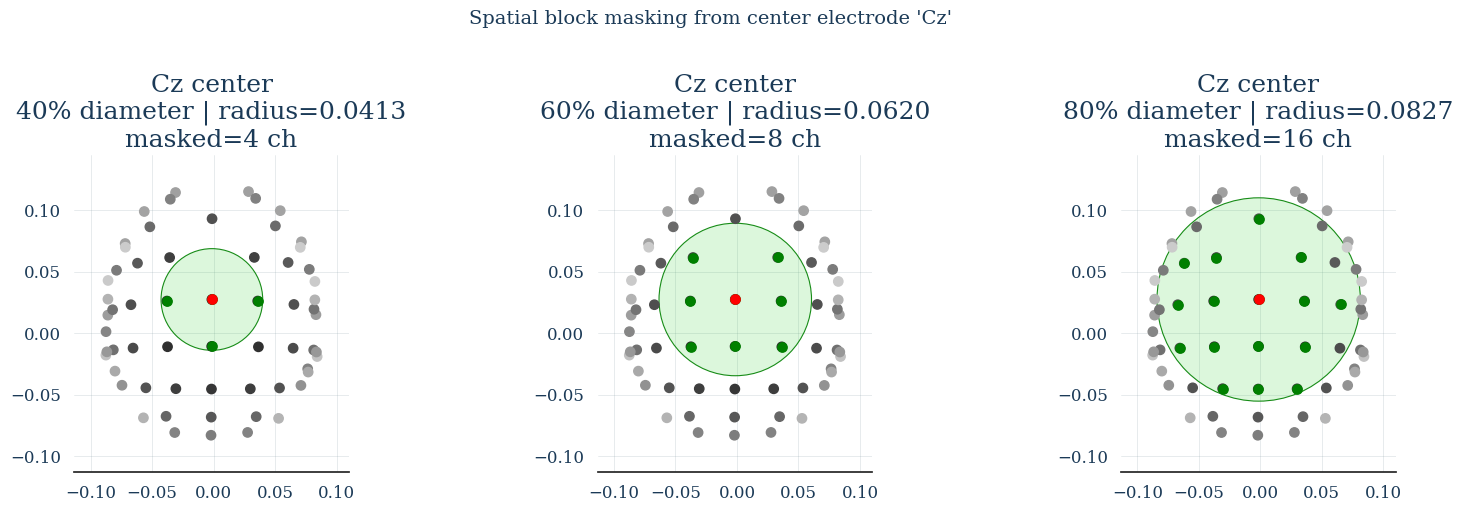

[2026-04-01 20:05:28] 40% mask around C6:
[2026-04-01 20:05:28]   radius: 0.041334
[2026-04-01 20:05:28]   masked channels (5): ['FC6', 'C4', 'T8', 'CP6', 'C6']

[2026-04-01 20:05:28] 60% mask around C6:
[2026-04-01 20:05:28]   radius: 0.062002
[2026-04-01 20:05:28]   masked channels (10): ['FC6', 'C4', 'T8', 'CP6', 'FC4', 'C6', 'CP4', 'FTT10h', 'TPP8h', 'TP8']

[2026-04-01 20:05:28] 80% mask around C6:
[2026-04-01 20:05:28]   radius: 0.082669
[2026-04-01 20:05:28]   masked channels (18): ['F4', 'F8', 'FC2', 'FC6', 'C4', 'T8', 'CP6', 'TP10', 'P4', 'P8', 'FC4', 'C2', 'C6', 'CP4', 'FTT10h', 'TPP8h', 'TP8', 'TPP10h']



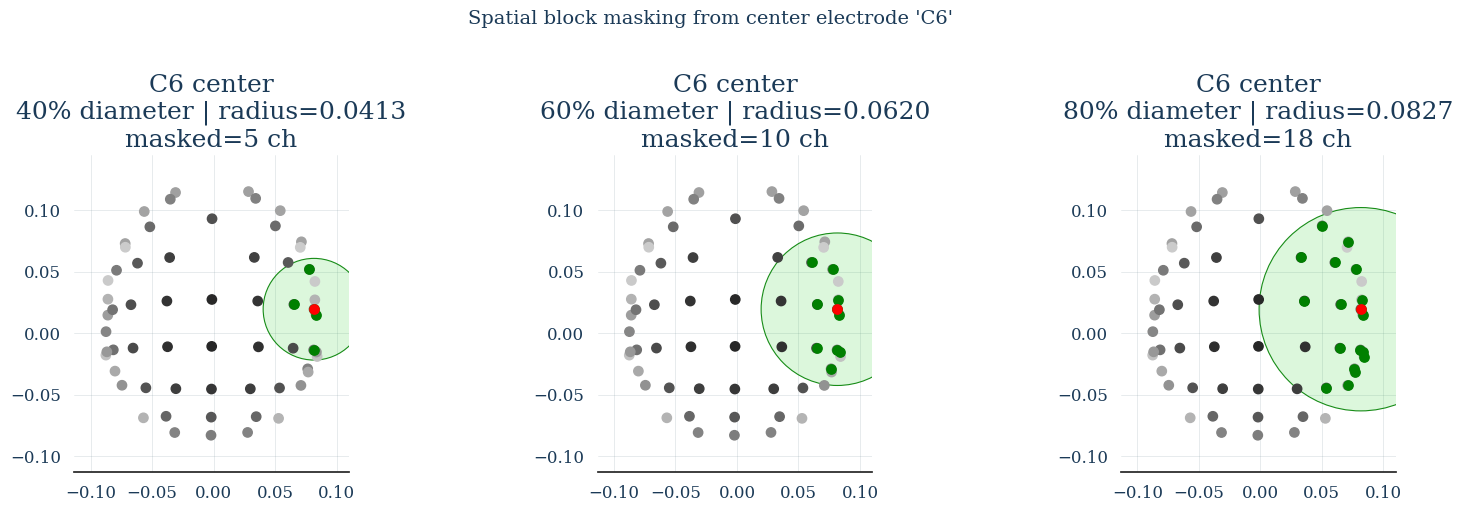

[2026-04-01 20:05:28] 40% mask around Oz:
[2026-04-01 20:05:28]   radius: 0.041334
[2026-04-01 20:05:28]   masked channels (4): ['O1', 'Oz', 'O2', 'POz']

[2026-04-01 20:05:28] 60% mask around Oz:
[2026-04-01 20:05:28]   radius: 0.062002
[2026-04-01 20:05:28]   masked channels (6): ['O1', 'Oz', 'O2', 'POz', 'PO3', 'PO4']

[2026-04-01 20:05:28] 80% mask around Oz:
[2026-04-01 20:05:28]   radius: 0.082669
[2026-04-01 20:05:28]   masked channels (13): ['P3', 'Pz', 'P4', 'PO9', 'O1', 'Oz', 'O2', 'PO10', 'P1', 'P2', 'POz', 'PO3', 'PO4']



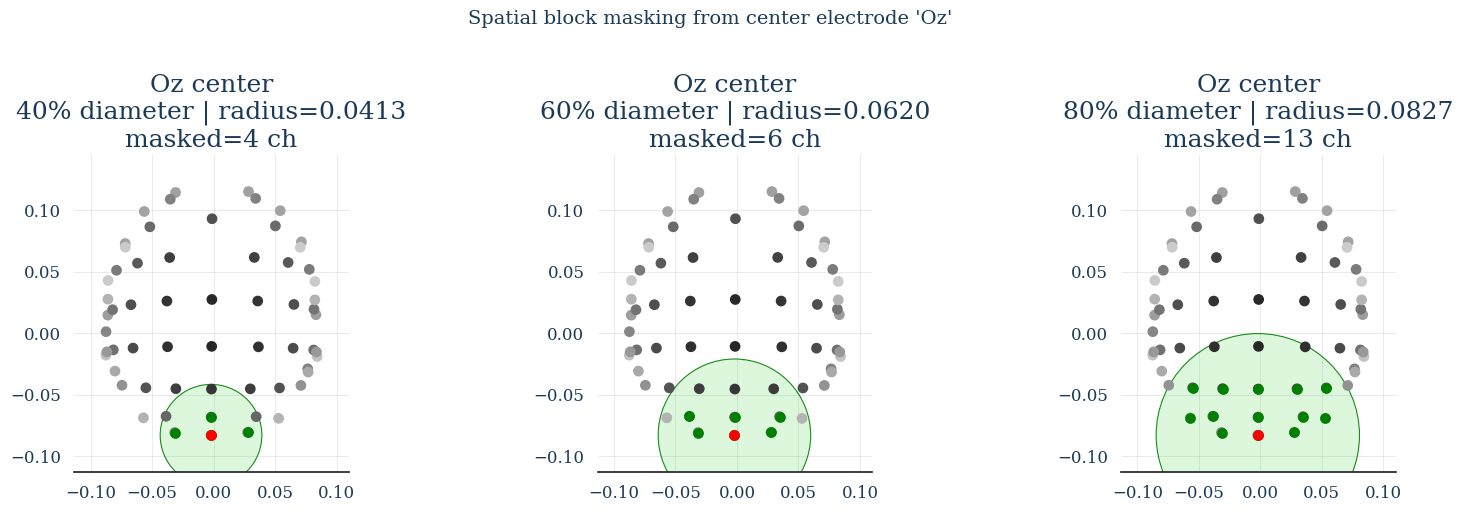

In [29]:
plot_sampler_masks(MASK_SAMPLER, center_name="Cz")
plot_sampler_masks(MASK_SAMPLER, center_name="C6")
plot_sampler_masks(MASK_SAMPLER, center_name="Oz")

[2026-04-01 20:05:28] 40% mask around Cz:
[2026-04-01 20:05:28]   radius: 0.041334
[2026-04-01 20:05:28]   masked channels (4): ['Cz', 'C1', 'C2', 'CPz']

[2026-04-01 20:05:28] 60% mask around Cz:
[2026-04-01 20:05:28]   radius: 0.062002
[2026-04-01 20:05:28]   masked channels (8): ['FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'C1', 'C2', 'CPz']

[2026-04-01 20:05:28] 80% mask around Cz:
[2026-04-01 20:05:28]   radius: 0.082669
[2026-04-01 20:05:28]   masked channels (16): ['Fz', 'FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2', 'Pz', 'FC3', 'C1', 'C2', 'CP3', 'CPz', 'P1', 'P2']



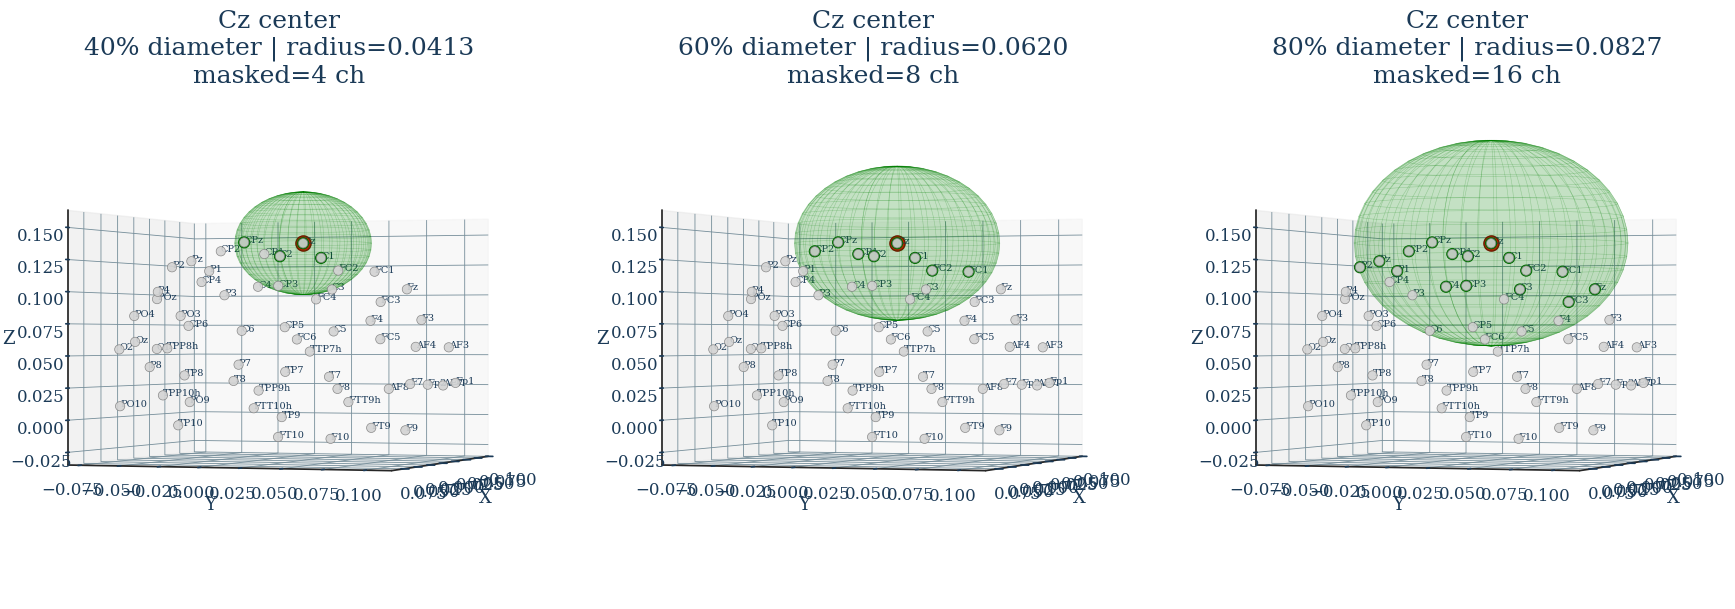

In [30]:
plot_sampler_masks_3d(MASK_SAMPLER, center_name="Cz", annotate=True, elev=0, azim=20)

## 4.3. Token-Routing Utilities

The helper functions below operate on a single sample at a time.
That keeps the routing logic correct even when the number of masked tokens varies across samples.

In [31]:
def expand_channel_mask_to_token_mask(mask_ch: torch.Tensor, n_tok_per_channel: int) -> torch.Tensor:
    """Expand a channel-level mask to token level.

    Supports either a single sample `(C,)` or a batch `(B, C)`.
    """
    if mask_ch.ndim == 1:
        return mask_ch.unsqueeze(-1).expand(-1, n_tok_per_channel).reshape(-1)
    if mask_ch.ndim == 2:
        return mask_ch.unsqueeze(-1).expand(-1, -1, n_tok_per_channel).reshape(mask_ch.shape[0], -1)
    raise ValueError(f"mask_ch must have ndim 1 or 2, got {mask_ch.ndim}")


def gather_visible_tokens_single(tokens: torch.Tensor, mask_tok: torch.Tensor) -> torch.Tensor:
    """Gather visible tokens for one sample.

    Parameters
    ----------
    tokens : FloatTensor `(N, D)`
    mask_tok : BoolTensor `(N,)`
    """
    return tokens[~mask_tok]


def gather_masked_tokens_single(tokens: torch.Tensor, mask_tok: torch.Tensor) -> torch.Tensor:
    """Gather masked tokens for one sample.

    Parameters
    ----------
    tokens : FloatTensor `(N, D)`
    mask_tok : BoolTensor `(N,)`
    """
    return tokens[mask_tok]

In [32]:
_, _fake_mask_tok, _fake_mask_info = MASK_SAMPLER.sample(2, device="cpu")

_fake_tokens = torch.randn(TOTAL_TOKENS, EMB_DIM)
_fake_visible = gather_visible_tokens_single(_fake_tokens, _fake_mask_tok[0])
_fake_masked = gather_masked_tokens_single(_fake_tokens, _fake_mask_tok[0])

print("Token-routing:")
print(f"  Full token shape:         {tuple(_fake_tokens.shape)}")
print(f"  Visible token shape:      {tuple(_fake_visible.shape)}")
print(f"  Masked token shape:       {tuple(_fake_masked.shape)}")
print(f"  Sample masked channels:   {_fake_mask_info['masked_channel_counts'][0]}")
print("Single-sample token routing validated OK.")

[2026-04-01 20:05:28] Token-routing:
[2026-04-01 20:05:28]   Full token shape:         (930, 64)
[2026-04-01 20:05:28]   Visible token shape:      (795, 64)
[2026-04-01 20:05:28]   Masked token shape:       (135, 64)
[2026-04-01 20:05:28]   Sample masked channels:   9
[2026-04-01 20:05:28] Single-sample token routing validated OK.


## 4.4. Predictor

The predictor maps student context to masked teacher targets.

Inputs:
- `student_context`: contextualized visible tokens `(1, N_vis, D)`
- `masked_pos_enc`: positional encodings of the masked positions `(1, N_masked, D)`

Output:
- predicted masked embeddings `(1, N_masked, D)`

In [33]:
class MaskedTokenPredictor(nn.Module):
    """Predicts masked token representations from student context.

    Architecture: Transformer decoder (cross-attention).

    Queries  = masked positional encodings  (B, N_masked, D)
    Keys/Vals = student contextual features (B, N_vis, D)
    Output   = predicted masked embeddings  (B, N_masked, D)
    """

    def __init__(
        self,
        d_model: int,
        nhead: int = 8,
        num_layers: int = 4,
        dim_feedforward: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_norm = nn.LayerNorm(d_model)

    def forward(self, student_context: torch.Tensor, masked_pos_enc: torch.Tensor) -> torch.Tensor:
        """Predict masked token embeddings."""
        decoded = self.decoder(tgt=masked_pos_enc, memory=student_context)
        return self.output_norm(decoded)

In [34]:
PREDICTOR = MaskedTokenPredictor(
    d_model=EMB_DIM,
    nhead=CONFIG["predictor_nhead"],
    num_layers=CONFIG["predictor_n_layers"],
    dim_feedforward=CONFIG["predictor_dim_feedforward"],
).to(DEVICE)

predictor_param_count = sum(parameter.numel() for parameter in PREDICTOR.parameters())
print("MaskedTokenPredictor initialized:")
print(f"  d_model:          {EMB_DIM}")
print(f"  nhead:            {CONFIG['predictor_nhead']}")
print(f"  num_layers:       {CONFIG['predictor_n_layers']}")
print(f"  dim_feedforward:  {CONFIG['predictor_dim_feedforward']}")
print(f"  Total parameters: {predictor_param_count:,}")

_, _test_mask_tok, _ = MASK_SAMPLER.sample(1, device=DEVICE)
_test_n_masked = int(_test_mask_tok[0].sum().item())
_test_n_visible = int((~_test_mask_tok[0]).sum().item())

_fake_student_context = torch.randn(1, _test_n_visible, EMB_DIM, device=DEVICE)
_fake_masked_pos = torch.randn(1, _test_n_masked, EMB_DIM, device=DEVICE)

PREDICTOR.eval()
with torch.no_grad():
    _pred_out = PREDICTOR(_fake_student_context, _fake_masked_pos)

if _pred_out.shape != (1, _test_n_masked, EMB_DIM):
    raise RuntimeError(
        f"Predictor output shape mismatch: got {tuple(_pred_out.shape)} expected {(1, _test_n_masked, EMB_DIM)}"
    )

print("\nPredictor shape test: OK")
print(f"  student_context: {tuple(_fake_student_context.shape)}")
print(f"  masked_pos_enc:  {tuple(_fake_masked_pos.shape)}")
print(f"  prediction:      {tuple(_pred_out.shape)}")
PREDICTOR.train()

[2026-04-01 20:05:28] MaskedTokenPredictor initialized:
[2026-04-01 20:05:28]   d_model:          64
[2026-04-01 20:05:28]   nhead:            8
[2026-04-01 20:05:28]   num_layers:       4
[2026-04-01 20:05:28]   dim_feedforward:  256
[2026-04-01 20:05:28]   Total parameters: 267,136

[2026-04-01 20:05:28] Predictor shape test: OK
[2026-04-01 20:05:28]   student_context: (1, 780, 64)
[2026-04-01 20:05:28]   masked_pos_enc:  (1, 150, 64)
[2026-04-01 20:05:28]   prediction:      (1, 150, 64)


MaskedTokenPredictor(
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
        (dropout3): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (ou

# 5. Training

## 5.1. Training Step, Validation Step, and EMA Update

The student/teacher/predictor path remains standard S-JEPA:
- teacher sees the full token sequence
- student sees only visible tokens
- predictor receives student context plus masked positional encodings
- masked-token L1 is computed against teacher contextual targets
- teacher is updated only through EMA

Because mask sizes vary across samples, each sample is processed independently inside the batch helper.

In [35]:
def masked_l1_loss(predicted: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """L1 loss on masked-token embeddings only."""
    return F.l1_loss(predicted, target)


@torch.no_grad()
def ema_update(student: nn.Module, teacher: nn.Module, ema_decay: float) -> None:
    """Update teacher parameters by exponential moving average from the student."""
    for student_param, teacher_param in zip(student.parameters(), teacher.parameters()):
        teacher_param.data.mul_(ema_decay).add_(student_param.data, alpha=1.0 - ema_decay)


def compute_single_sample_loss(x_single, student, teacher, predictor, mask_sampler, device, debug=False):
    """Compute the masked-token prediction loss for one sample."""
    x_single = x_single.unsqueeze(0).to(device)
    _, mask_tok, mask_info = mask_sampler.sample(1, device=device)
    mask_tok_single = mask_tok[0]

    if not bool(mask_tok_single.any()):
        raise RuntimeError("Mask sampler produced zero masked tokens.")
    if not bool((~mask_tok_single).any()):
        raise RuntimeError("Mask sampler masked every token in the sample.")

    teacher.eval()

    # Teacher target path uses current student local tokens + EMA contextual encoder.
    with torch.no_grad():
        teacher_local = student.feature_encoder(x_single)
        teacher_pos = student.pos_encoder(teacher_local)
        teacher_full_tokens = teacher_local + teacher_pos
        teacher_context = teacher.transformer.encoder(teacher_full_tokens)
        teacher_masked = teacher_context[:, mask_tok_single, :]

    student_local = student.feature_encoder(x_single)
    student_pos = student.pos_encoder(student_local)
    student_full_tokens = student_local + student_pos
    student_visible_tokens = student_full_tokens[:, ~mask_tok_single, :]
    masked_positional_queries = student_pos[:, mask_tok_single, :]
    student_context = student.transformer.encoder(student_visible_tokens)
    predicted_masked = predictor(student_context, masked_positional_queries)

    # Fail fast on any non-finite intermediate before loss/backprop.
    assert_finite_tensor("teacher_local", teacher_local)
    assert_finite_tensor("teacher_pos", teacher_pos)
    assert_finite_tensor("teacher_full_tokens", teacher_full_tokens)
    assert_finite_tensor("teacher_context", teacher_context)
    assert_finite_tensor("teacher_masked", teacher_masked)
    assert_finite_tensor("student_local", student_local)
    assert_finite_tensor("student_pos", student_pos)
    assert_finite_tensor("student_full_tokens", student_full_tokens)
    assert_finite_tensor("student_visible_tokens", student_visible_tokens)
    assert_finite_tensor("student_context", student_context)
    assert_finite_tensor("masked_positional_queries", masked_positional_queries)
    assert_finite_tensor("predicted_masked", predicted_masked)

    loss = masked_l1_loss(predicted_masked, teacher_masked.detach())
    assert_finite_tensor("loss", loss)

    sample_stats = {
        "center_channel": int(mask_info["center_indices"][0]),
        "masked_channels": int(mask_info["masked_channel_counts"][0]),
        "masked_tokens": int(mask_info["masked_token_counts"][0]),
        "visible_tokens": int((~mask_tok_single).sum().item()),
    }

    if debug:
        print("  [debug] first-sample training path:")
        print(f"    x_single:             {tuple(x_single.shape)}")
        print(f"    teacher_full_tokens:  {tuple(teacher_full_tokens.shape)}")
        print(f"    student_visible:      {tuple(student_visible_tokens.shape)}")
        print(f"    masked_queries:       {tuple(masked_positional_queries.shape)}")
        print(f"    predicted_masked:     {tuple(predicted_masked.shape)}")
        print(f"    teacher_masked:       {tuple(teacher_masked.shape)}")
        print(f"    center_channel:       {sample_stats['center_channel']}")
        print(f"    masked_channels:      {sample_stats['masked_channels']}")
        print(f"    masked_tokens:        {sample_stats['masked_tokens']}")
        print(f"    visible_tokens:       {sample_stats['visible_tokens']}")
        print(f"    sample_loss:          {loss.item():.6f}")

    return loss, sample_stats


def _aggregate_batch_stats(sample_stats):
    return {
        "mean_masked_channels": float(sum(s["masked_channels"] for s in sample_stats) / len(sample_stats)),
        "mean_masked_tokens": float(sum(s["masked_tokens"] for s in sample_stats) / len(sample_stats)),
        "mean_visible_tokens": float(sum(s["visible_tokens"] for s in sample_stats) / len(sample_stats)),
        "sample_stats": sample_stats,
    }


def process_batch_low_memory(
    X_cpu,
    student,
    teacher,
    predictor,
    mask_sampler,
    optimizer,
    ema_decay,
    device,
    training,
    debug=False,
    apply_update=True,
    backprop=True,
):
    """Process one batch with minimal peak memory by handling one sample at a time."""
    n_samples = int(X_cpu.shape[0])
    if n_samples == 0:
        raise RuntimeError("Received an empty batch.")

    sample_stats = []
    running_loss = 0.0

    if training and apply_update:
        optimizer.zero_grad(set_to_none=True)

    for sample_idx in range(n_samples):
        x_sample = X_cpu[sample_idx].float()
        sample_loss, stats = compute_single_sample_loss(
            x_sample,
            student=student,
            teacher=teacher,
            predictor=predictor,
            mask_sampler=mask_sampler,
            device=device,
            debug=debug and sample_idx == 0,
        )

        if not torch.isfinite(sample_loss):
            raise RuntimeError("Non-finite sample loss detected.")

        if training and apply_update and backprop:
            (sample_loss / n_samples).backward()

        running_loss += float(sample_loss.detach().item())
        sample_stats.append(stats)

        del sample_loss, x_sample

    if training and apply_update:
        optimizer.step()
        ema_update(student.transformer.encoder, teacher.transformer.encoder, ema_decay)

    batch_stats = _aggregate_batch_stats(sample_stats)
    return {
        "loss": float(running_loss / n_samples),
        **batch_stats,
    }


def pretraining_step(
    X,
    student,
    teacher,
    predictor,
    mask_sampler,
    optimizer,
    ema_decay,
    device,
    debug=False,
):
    student.train()
    predictor.train()
    teacher.eval()

    batch_result = process_batch_low_memory(
        X_cpu=X,
        student=student,
        teacher=teacher,
        predictor=predictor,
        mask_sampler=mask_sampler,
        optimizer=optimizer,
        ema_decay=ema_decay,
        device=device,
        training=True,
        debug=debug,
        apply_update=True,
        backprop=True,
    )

    return {
        "loss": batch_result["loss"],
        "mean_masked_channels": batch_result["mean_masked_channels"],
        "mean_masked_tokens": batch_result["mean_masked_tokens"],
        "mean_visible_tokens": batch_result["mean_visible_tokens"],
    }


def evaluate_pretraining_batch(X, student, teacher, predictor, mask_sampler, device):
    """Evaluate one validation batch without parameter updates."""
    student.eval()
    predictor.eval()
    teacher.eval()

    with torch.no_grad():
        batch_result = process_batch_low_memory(
            X_cpu=X,
            student=student,
            teacher=teacher,
            predictor=predictor,
            mask_sampler=mask_sampler,
            optimizer=None,
            ema_decay=None,
            device=device,
            training=False,
            debug=False,
            apply_update=False,
            backprop=False,
        )

    return batch_result

In [36]:
OPTIMIZER = torch.optim.Adam(
    list(STUDENT.parameters()) + list(PREDICTOR.parameters()),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

_debug_train_subject_chunk = next(
    iter_subject_chunks(
        TRAIN_SUBJECTS,
        chunk_size=CONFIG["train_subject_chunk_size"],
        shuffle=False,
    )
)
_debug_train_windows, _debug_train_raw, _ = prepare_pretraining_chunk_dataset(
    paradigm_names=CONFIG["paradigm_names"],
    subject_ids=_debug_train_subject_chunk,
    split_name="debug-train",
    preprocessors=_PREPROCESSORS,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
    preload=CONFIG["window_preload"],
)
_debug_train_loader = make_chunk_dataloader(
    windows_dataset=_debug_train_windows,
    batch_size=CONFIG["batch_size"],
    training=True,
)

_debug_val_subject_chunk = next(
    iter_subject_chunks(
        VAL_SUBJECTS,
        chunk_size=CONFIG["val_subject_chunk_size"],
        shuffle=False,
    )
)
_debug_val_windows, _debug_val_raw, _ = prepare_pretraining_chunk_dataset(
    paradigm_names=CONFIG["paradigm_names"],
    subject_ids=_debug_val_subject_chunk,
    split_name="debug-validation",
    preprocessors=_PREPROCESSORS,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
    preload=CONFIG["window_preload"],
)
_debug_val_loader = make_chunk_dataloader(
    windows_dataset=_debug_val_windows,
    batch_size=CONFIG["batch_size"],
    training=False,
)

print("Optimizer: Adam")
print(f"Learning rate:             {CONFIG['learning_rate']}")
print(f"Weight decay:              {CONFIG['weight_decay']}")
print(f"Debug train chunk subjects: {_debug_train_subject_chunk}")
print(f"Debug train windows:        {len(_debug_train_windows)}")
print(f"Debug val chunk subjects:   {_debug_val_subject_chunk}")
print(f"Debug val windows:          {len(_debug_val_windows)}")

print("\nRunning first-batch debug (dry-run before optimizer step)...")
set_seed(CONFIG["seed"])

_debug_batch = next(iter(_debug_train_loader))
_debug_X = _debug_batch[0].float()

# Dry-run finite check: one-sample-at-a-time forward path without parameter updates.
_dry_run_result = process_batch_low_memory(
    X_cpu=_debug_X,
    student=STUDENT,
    teacher=TEACHER,
    predictor=PREDICTOR,
    mask_sampler=MASK_SAMPLER,
    optimizer=OPTIMIZER,
    ema_decay=CONFIG["ema_decay"],
    device=DEVICE,
    training=True,
    debug=True,
    apply_update=False,
    backprop=False,
)
if not np.isfinite(_dry_run_result["loss"]):
    raise RuntimeError("Dry-run first training batch produced a non-finite loss.")
print(f"  Dry-run first training-batch loss: {_dry_run_result['loss']:.6f}")

# Now run one real optimizer update only after finite dry-run passes.
_debug_train_result = pretraining_step(
    X=_debug_X,
    student=STUDENT,
    teacher=TEACHER,
    predictor=PREDICTOR,
    mask_sampler=MASK_SAMPLER,
    optimizer=OPTIMIZER,
    ema_decay=CONFIG["ema_decay"],
    device=DEVICE,
    debug=False,
)
print(f"  First training-batch loss (updated): {_debug_train_result['loss']:.6f}")
print(f"  Mean masked channels:               {_debug_train_result['mean_masked_channels']:.2f}")
print(f"  Mean masked tokens:                 {_debug_train_result['mean_masked_tokens']:.2f}")

_validation_batch = next(iter(_debug_val_loader))
_validation_result = evaluate_pretraining_batch(
    X=_validation_batch[0].float(),
    student=STUDENT,
    teacher=TEACHER,
    predictor=PREDICTOR,
    mask_sampler=MASK_SAMPLER,
    device=DEVICE,
)
print(f"  First validation-batch loss: {_validation_result['loss']:.6f}")

if not np.isfinite(_debug_train_result["loss"]):
    raise RuntimeError("First training batch produced a non-finite loss.")
if not np.isfinite(_validation_result["loss"]):
    raise RuntimeError("First validation batch produced a non-finite loss.")

del _debug_train_loader, _debug_val_loader
del _debug_train_windows, _debug_train_raw, _debug_val_windows, _debug_val_raw
gc.collect()

[2026-04-01 20:07:46] Optimizer: Adam
[2026-04-01 20:07:46] Learning rate:             0.001
[2026-04-01 20:07:46] Weight decay:              0.0
[2026-04-01 20:07:46] Debug train chunk subjects: [1, 2]
[2026-04-01 20:07:46] Debug train windows:        596
[2026-04-01 20:07:46] Debug val chunk subjects:   [41]
[2026-04-01 20:07:46] Debug val windows:          298

[2026-04-01 20:07:46] Running first-batch debug (dry-run before optimizer step)...
[2026-04-01 20:07:46]   [debug] first-sample training path:
[2026-04-01 20:07:46]     x_single:             (1, 62, 2048)
[2026-04-01 20:07:46]     teacher_full_tokens:  (1, 930, 64)
[2026-04-01 20:07:46]     student_visible:      (1, 795, 64)
[2026-04-01 20:07:46]     masked_queries:       (1, 135, 64)
[2026-04-01 20:07:46]     predicted_masked:     (1, 135, 64)
[2026-04-01 20:07:46]     teacher_masked:       (1, 135, 64)
[2026-04-01 20:07:46]     center_channel:       40
[2026-04-01 20:07:46]     masked_channels:      9
[2026-04-01 20:07:46] 

3160

## 5.2. Epoch Loop, Validation, Early Stopping, and Checkpoints

Each epoch now runs:
- one full chunked training pass over all train subject chunks
- one full chunked validation pass over all validation subject chunks
- latest checkpoint save
- best checkpoint update based on aggregated full-validation loss
- patience-based early stopping on full-validation loss
- `epoch_metrics.jsonl` append

In [37]:
import time


def build_backbone_export_metadata():
    """Metadata needed to reconstruct the pretrained student backbone later."""
    return {
        "conv_layers_spec": [list(spec) for spec in _DEFAULT_CONV_LAYER_SPEC],
        "sfreq": CONFIG["sfreq"],
        "input_window_seconds": INPUT_WINDOW_SECONDS,
        "chs_info": CHS_INFO,
        "ch_names": CH_NAMES,
        "token_geometry": {
            "n_channels": N_CHANNELS,
            "n_tok_per_channel": N_TOK_PER_CHANNEL,
            "emb_dim": EMB_DIM,
            "total_tokens": TOTAL_TOKENS,
        },
        "masking_config": {
            "strategy": CONFIG["masking_strategy"],
            "mask_diameter_percent": CONFIG["mask_diameter_percent"],
            "head_diameter": MASK_SAMPLER.head_diameter,
            "mask_diameter": MASK_SAMPLER.mask_diameter,
            "mask_radius": MASK_SAMPLER.mask_radius,
        },
        "preprocessing_config": {
            "sfreq": CONFIG["sfreq"],
            "bandpass_low": CONFIG["bandpass_low"],
            "bandpass_high": CONFIG["bandpass_high"],
            "pretrain_duration_s": CONFIG["pretrain_duration_s"],
            "sampling_interval_s": CONFIG["sampling_interval_s"],
            "window_size_samples": WINDOW_SIZE_SAMPLES,
            "sampling_interval_samples": SAMPLING_INTERVAL_SAMPLES,
        },
        "subject_split": {
            "train_subject_ids": TRAIN_SUBJECTS,
            "val_subject_ids": VAL_SUBJECTS,
            "excluded_subject_ids": DOWNSTREAM_ONLY_SUBJECTS,
        },
    }


BACKBONE_EXPORT_METADATA = build_backbone_export_metadata()


def save_checkpoint(artifact_dir, tag, student, teacher, predictor, optimizer, epoch, epoch_record, metrics_so_far):
    """Save a full training checkpoint."""
    checkpoint = {
        "epoch": epoch,
        "epoch_record": epoch_record,
        "student_state_dict": student.state_dict(),
        "teacher_state_dict": teacher.state_dict(),
        "predictor_state_dict": predictor.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "metrics": metrics_so_far,
        "backbone_export_metadata": BACKBONE_EXPORT_METADATA,
    }
    checkpoint_path = Path(artifact_dir) / f"checkpoint_{tag}.pt"
    torch.save(checkpoint, checkpoint_path)
    return str(checkpoint_path)


def save_student_backbone_export(artifact_dir, tag, student):
    """Save a dedicated student-backbone export for downstream fine-tuning."""
    export_payload = {
        "student_backbone_state_dict": student.state_dict(),
        **BACKBONE_EXPORT_METADATA,
    }
    export_path = Path(artifact_dir) / f"student_backbone_{tag}.pt"
    torch.save(export_payload, export_path)
    return str(export_path)


def append_epoch_metrics(artifact_dir, epoch_record):
    """Append one epoch record to epoch_metrics.jsonl."""
    epoch_metrics_path = Path(artifact_dir) / "epoch_metrics.jsonl"
    with open(epoch_metrics_path, "a") as metric_file:
        metric_file.write(json.dumps(epoch_record) + "\n")

In [38]:
def run_pretraining_epoch_chunked(
    epoch,
    split_name,
    subject_ids,
    chunk_size,
    chunk_shuffle,
    paradigm_names,
    preprocessors,
    window_size_samples,
    sampling_interval_samples,
    preload,
    batch_size,
    training,
    student,
    teacher,
    predictor,
    mask_sampler,
    optimizer,
    ema_decay,
    device,
    seed,
):
    """Run one train or validation epoch by streaming subject chunks."""
    epoch_start = time.time()
    batch_losses = []
    masked_channels = []
    masked_tokens = []
    visible_tokens = []

    chunk_losses = []
    chunk_window_counts = []
    chunk_recording_counts = []
    n_batches_total = 0

    chunk_subject_lists = list(
        iter_subject_chunks(
            subject_ids=subject_ids,
            chunk_size=chunk_size,
            shuffle=chunk_shuffle and training,
            seed=seed + int(epoch),
        )
    )
    if len(chunk_subject_lists) == 0:
        raise RuntimeError(f"{split_name} subject split produced zero chunks.")

    log_debug(
        f"[debug] [{split_name}] epoch {epoch}: "
        f"chunks={len(chunk_subject_lists)} chunk_size={chunk_size} "
        f"shuffle={bool(chunk_shuffle and training)} preload={preload}"
    )

    for chunk_idx, chunk_subjects in enumerate(chunk_subject_lists, start=1):
        chunk_windows = None
        chunk_raw_dataset = None
        chunk_loader = None
        chunk_start_time = time.time()
        try:
            log_debug(
                f"[debug] [{split_name}] epoch {epoch} chunk {chunk_idx}/{len(chunk_subject_lists)} "
                f"subjects={chunk_subjects} paradigms={list(paradigm_names)}"
            )

            chunk_windows, chunk_raw_dataset, chunk_recordings_by_paradigm = prepare_pretraining_chunk_dataset(
                paradigm_names=paradigm_names,
                subject_ids=chunk_subjects,
                split_name=split_name,
                preprocessors=preprocessors,
                window_size_samples=window_size_samples,
                sampling_interval_samples=sampling_interval_samples,
                preload=preload,
            )

            chunk_recording_count = len(chunk_raw_dataset.datasets)
            chunk_window_count = len(chunk_windows)
            chunk_loader = make_chunk_dataloader(
                windows_dataset=chunk_windows,
                batch_size=batch_size,
                training=training,
            )

            per_chunk_batch_losses = []
            per_chunk_masked_channels = []
            per_chunk_masked_tokens = []
            per_chunk_visible_tokens = []

            for batch in chunk_loader:
                X = batch[0].float()
                if training:
                    batch_result = pretraining_step(
                        X=X,
                        student=student,
                        teacher=teacher,
                        predictor=predictor,
                        mask_sampler=mask_sampler,
                        optimizer=optimizer,
                        ema_decay=ema_decay,
                        device=device,
                        debug=False,
                    )
                else:
                    batch_result = evaluate_pretraining_batch(
                        X=X,
                        student=student,
                        teacher=teacher,
                        predictor=predictor,
                        mask_sampler=mask_sampler,
                        device=device,
                    )

                loss_value = float(batch_result["loss"])
                per_chunk_batch_losses.append(loss_value)
                per_chunk_masked_channels.append(float(batch_result["mean_masked_channels"]))
                per_chunk_masked_tokens.append(float(batch_result["mean_masked_tokens"]))
                per_chunk_visible_tokens.append(float(batch_result["mean_visible_tokens"]))

                batch_losses.append(loss_value)
                masked_channels.append(float(batch_result["mean_masked_channels"]))
                masked_tokens.append(float(batch_result["mean_masked_tokens"]))
                visible_tokens.append(float(batch_result["mean_visible_tokens"]))
                n_batches_total += 1

            if len(per_chunk_batch_losses) == 0:
                raise RuntimeError(
                    f"{split_name} chunk {chunk_subjects} produced zero batches; "
                    "adjust chunk size or batch_size/drop_last settings."
                )

            chunk_mean_loss = float(np.mean(per_chunk_batch_losses))
            chunk_losses.append(chunk_mean_loss)
            chunk_window_counts.append(chunk_window_count)
            chunk_recording_counts.append(chunk_recording_count)

            chunk_elapsed = time.time() - chunk_start_time
            print(
                f"[{split_name}] epoch {epoch} chunk {chunk_idx}/{len(chunk_subject_lists)} "
                f"subjects={chunk_subjects} windows={chunk_window_count} "
                f"batches={len(per_chunk_batch_losses)} loss={chunk_mean_loss:.6f} "
                f"running={float(np.mean(batch_losses)):.6f} "
                f"time={chunk_elapsed:.1f}s"
            )

        finally:
            del chunk_loader, chunk_windows, chunk_raw_dataset
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    if not batch_losses:
        raise RuntimeError(f"{split_name} epoch produced zero batches across all chunks.")

    epoch_time_s = time.time() - epoch_start
    return {
        "epoch": int(epoch),
        "split": split_name,
        "mean_loss": float(np.mean(batch_losses)),
        "min_loss": float(np.min(batch_losses)),
        "max_loss": float(np.max(batch_losses)),
        "mean_masked_channels": float(np.mean(masked_channels)),
        "mean_masked_tokens": float(np.mean(masked_tokens)),
        "mean_visible_tokens": float(np.mean(visible_tokens)),
        "n_batches": int(len(batch_losses)),
        "n_chunks": int(len(chunk_subject_lists)),
        "mean_chunk_loss": float(np.mean(chunk_losses)),
        "mean_chunk_windows": float(np.mean(chunk_window_counts)),
        "mean_chunk_recordings": float(np.mean(chunk_recording_counts)),
        "epoch_time_s": round(epoch_time_s, 2),
    }

In [39]:
_train_chunk_count = len(list(iter_subject_chunks(
    TRAIN_SUBJECTS,
    chunk_size=CONFIG["train_subject_chunk_size"],
    shuffle=False,
)))
_val_chunk_count = len(list(iter_subject_chunks(
    VAL_SUBJECTS,
    chunk_size=CONFIG["val_subject_chunk_size"],
    shuffle=False,
)))

print("=" * 70)
print("[setup] STARTING LEE2019 S-JEPA PRETRAINING")
print("=" * 70)
print(f"[setup] run_id:                  {RUN_ID}")
print(f"[setup] seed:                    {CONFIG['seed']}")
print(f"[setup] device:                  {DEVICE}")
print(f"[setup] paradigms:               {CONFIG['paradigm_names']}")
print(f"[setup] train_subjects:          {len(TRAIN_SUBJECTS)}  {TRAIN_SUBJECTS}")
print(f"[setup] val_subjects:            {len(VAL_SUBJECTS)}  {VAL_SUBJECTS}")
print(f"[setup] excluded_subjects:       {DOWNSTREAM_ONLY_SUBJECTS}")
print(f"[setup] train_chunk_size:        {CONFIG['train_subject_chunk_size']}")
print(f"[setup] val_chunk_size:          {CONFIG['val_subject_chunk_size']}")
print(f"[setup] train_chunks_per_epoch:  {_train_chunk_count}")
print(f"[setup] val_chunks_per_epoch:    {_val_chunk_count}")
print(f"[setup] batch_size:              {CONFIG['batch_size']}")
print(f"[setup] early_stopping_patience: {CONFIG['early_stopping_patience']}")
print(f"[setup] window_preload:          {CONFIG['window_preload']}")
print(f"[setup] pretrain_duration:       {CONFIG['pretrain_duration_s']} s")
print(f"[setup] sampling_interval:       {CONFIG['sampling_interval_s']} s")
print(f"[setup] mask_diameter:           {CONFIG['mask_diameter_percent']}%")
print(f"[setup] ema_decay:               {CONFIG['ema_decay']}")
print(f"[setup] epoch_limit:             {CONFIG['n_epochs']}")
print(f"[setup] log_verbosity:           {LOG_VERBOSITY}")
print("=" * 70)

set_seed(CONFIG["seed"])

EPOCH_METRICS = []
BEST_VAL_LOSS = float("inf")
BEST_EPOCH = -1
PATIENCE_COUNTER = 0
STOP_REASON = "max_epochs_reached"

for epoch in range(1, CONFIG["n_epochs"] + 1):
    train_metrics = run_pretraining_epoch_chunked(
        epoch=epoch,
        split_name="train",
        subject_ids=TRAIN_SUBJECTS,
        chunk_size=CONFIG["train_subject_chunk_size"],
        chunk_shuffle=CONFIG["chunk_shuffle"],
        paradigm_names=CONFIG["paradigm_names"],
        preprocessors=_PREPROCESSORS,
        window_size_samples=WINDOW_SIZE_SAMPLES,
        sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
        preload=CONFIG["window_preload"],
        batch_size=CONFIG["batch_size"],
        training=True,
        student=STUDENT,
        teacher=TEACHER,
        predictor=PREDICTOR,
        mask_sampler=MASK_SAMPLER,
        optimizer=OPTIMIZER,
        ema_decay=CONFIG["ema_decay"],
        device=DEVICE,
        seed=CONFIG["seed"],
    )
    val_metrics = run_pretraining_epoch_chunked(
        epoch=epoch,
        split_name="val",
        subject_ids=VAL_SUBJECTS,
        chunk_size=CONFIG["val_subject_chunk_size"],
        chunk_shuffle=False,
        paradigm_names=CONFIG["paradigm_names"],
        preprocessors=_PREPROCESSORS,
        window_size_samples=WINDOW_SIZE_SAMPLES,
        sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
        preload=CONFIG["window_preload"],
        batch_size=CONFIG["batch_size"],
        training=False,
        student=STUDENT,
        teacher=TEACHER,
        predictor=PREDICTOR,
        mask_sampler=MASK_SAMPLER,
        optimizer=OPTIMIZER,
        ema_decay=CONFIG["ema_decay"],
        device=DEVICE,
        seed=CONFIG["seed"],
    )

    improved = val_metrics["mean_loss"] < BEST_VAL_LOSS
    if improved:
        BEST_VAL_LOSS = val_metrics["mean_loss"]
        BEST_EPOCH = epoch
        PATIENCE_COUNTER = 0
    else:
        PATIENCE_COUNTER += 1

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["mean_loss"],
        "val_loss": val_metrics["mean_loss"],
        "train_masked_channels": train_metrics["mean_masked_channels"],
        "val_masked_channels": val_metrics["mean_masked_channels"],
        "train_masked_tokens": train_metrics["mean_masked_tokens"],
        "val_masked_tokens": val_metrics["mean_masked_tokens"],
        "train_visible_tokens": train_metrics["mean_visible_tokens"],
        "val_visible_tokens": val_metrics["mean_visible_tokens"],
        "train_batches": train_metrics["n_batches"],
        "val_batches": val_metrics["n_batches"],
        "train_chunks": train_metrics["n_chunks"],
        "val_chunks": val_metrics["n_chunks"],
        "train_time_s": train_metrics["epoch_time_s"],
        "val_time_s": val_metrics["epoch_time_s"],
        "best_val_loss": BEST_VAL_LOSS,
        "best_epoch": BEST_EPOCH,
        "patience_counter": PATIENCE_COUNTER,
        "improved_val": improved,
    }
    EPOCH_METRICS.append(epoch_record)
    append_epoch_metrics(ARTIFACT_DIR, epoch_record)

    save_checkpoint(
        ARTIFACT_DIR,
        "latest",
        STUDENT,
        TEACHER,
        PREDICTOR,
        OPTIMIZER,
        epoch,
        epoch_record,
        EPOCH_METRICS,
    )
    save_student_backbone_export(ARTIFACT_DIR, "latest", STUDENT)

    if improved:
        save_checkpoint(
            ARTIFACT_DIR,
            "best",
            STUDENT,
            TEACHER,
            PREDICTOR,
            OPTIMIZER,
            epoch,
            epoch_record,
            EPOCH_METRICS,
        )
        save_student_backbone_export(ARTIFACT_DIR, "best", STUDENT)

    print(
        f"[epoch] {epoch:3d}/{CONFIG['n_epochs']}  "
        f"train_loss={train_metrics['mean_loss']:.6f}  "
        f"val_loss={val_metrics['mean_loss']:.6f}  "
        f"best_val={BEST_VAL_LOSS:.6f}  "
        f"patience={PATIENCE_COUNTER}/{CONFIG['early_stopping_patience']}  "
        f"train_chunks={train_metrics['n_chunks']}  "
        f"val_chunks={val_metrics['n_chunks']}  "
        f"train_time={train_metrics['epoch_time_s']:.1f}s  "
        f"val_time={val_metrics['epoch_time_s']:.1f}s"
    )

    if PATIENCE_COUNTER >= CONFIG["early_stopping_patience"]:
        STOP_REASON = "early_stopping"
        print(
            f"[epoch] early stopping triggered after epoch {epoch}: "
            f"no validation improvement for {CONFIG['early_stopping_patience']} epochs."
        )
        break

print("=" * 70)
print(f"[epoch] training complete. Best val loss: {BEST_VAL_LOSS:.6f} at epoch {BEST_EPOCH}.")
print(f"[epoch] stop reason: {STOP_REASON}")
print("=" * 70)

[2026-04-01 20:08:09] ======================================================================
[2026-04-01 20:08:09] [setup] STARTING LEE2019 S-JEPA PRETRAINING
[2026-04-01 20:08:09] ======================================================================
[2026-04-01 20:08:09] [setup] run_id:                  20260401_2002_c4482f4c
[2026-04-01 20:08:09] [setup] seed:                    42
[2026-04-01 20:08:09] [setup] device:                  cpu
[2026-04-01 20:08:09] [setup] paradigms:               ['MI', 'ERP', 'SSVEP']
[2026-04-01 20:08:09] [setup] train_subjects:          40  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
[2026-04-01 20:08:09] [setup] val_subjects:            7  [41, 42, 43, 44, 45, 46, 47]
[2026-04-01 20:08:09] [setup] excluded_subjects:       [48, 49, 50, 51, 52, 53, 54]
[2026-04-01 20:08:09] [setup] train_chunk_size:        2
[2026-04-01 20:08:09] [setup] val_ch

# 6. Diagnostics

Lightweight post-training checks for reproducibility:
- train/validation loss history
- mask coverage statistics
- one-batch end-to-end shape inspection

## 6.1. Loss Curve Summary

In [40]:
print("=" * 70)
print("LOSS HISTORY SUMMARY")
print("=" * 70)

if EPOCH_METRICS:
    train_losses = [record["train_loss"] for record in EPOCH_METRICS]
    val_losses = [record["val_loss"] for record in EPOCH_METRICS]
    total_train_time = sum(record["train_time_s"] for record in EPOCH_METRICS)
    total_val_time = sum(record["val_time_s"] for record in EPOCH_METRICS)

    print(f"  Epochs completed:     {len(EPOCH_METRICS)}")
    print(f"  First train loss:     {train_losses[0]:.6f}")
    print(f"  Last train loss:      {train_losses[-1]:.6f}")
    print(f"  First val loss:       {val_losses[0]:.6f}")
    print(f"  Last val loss:        {val_losses[-1]:.6f}")
    print(f"  Best val loss:        {BEST_VAL_LOSS:.6f} (epoch {BEST_EPOCH})")
    print(f"  Total train time:     {total_train_time:.1f} s")
    print(f"  Total validation time:{total_val_time:.1f} s")
    print(f"  Stop reason:          {STOP_REASON}")
else:
    print("  No epoch metrics recorded.")

[2026-04-09 15:50:16] ======================================================================
[2026-04-09 15:50:16] LOSS HISTORY SUMMARY
[2026-04-09 15:50:16] ======================================================================
[2026-04-09 15:50:16]   Epochs completed:     103
[2026-04-09 15:50:16]   First train loss:     0.030072
[2026-04-09 15:50:16]   Last train loss:      0.000804
[2026-04-09 15:50:16]   First val loss:       0.008671
[2026-04-09 15:50:16]   Last val loss:        0.000871
[2026-04-09 15:50:16]   Best val loss:        0.000669 (epoch 93)
[2026-04-09 15:50:16]   Total train time:     636973.5 s
[2026-04-09 15:50:16]   Total validation time:38743.6 s
[2026-04-09 15:50:16]   Stop reason:          early_stopping


## 6.2. Mask Coverage Summary

In [41]:
def summarize_mask_coverage(mask_sampler: RandomSpatialBlockMaskSampler, n_samples: int = 200):
    """Sample mask coverage statistics for the current radius-based sampler."""
    masked_channel_counts = []
    masked_token_counts = []

    for _ in range(n_samples):
        _, _, mask_info = mask_sampler.sample(1, device="cpu")
        masked_channel_counts.append(mask_info["masked_channel_counts"][0])
        masked_token_counts.append(mask_info["masked_token_counts"][0])

    mask_stats = {
        "n_channels": mask_sampler.n_channels,
        "n_tok_per_channel": mask_sampler.n_tok_per_channel,
        "head_diameter": mask_sampler.head_diameter,
        "mask_diameter_percent": mask_sampler.mask_diameter_percent,
        "mask_diameter": mask_sampler.mask_diameter,
        "mask_radius": mask_sampler.mask_radius,
        "masked_channels_mean": float(np.mean(masked_channel_counts)),
        "masked_channels_min": int(np.min(masked_channel_counts)),
        "masked_channels_max": int(np.max(masked_channel_counts)),
        "masked_tokens_mean": float(np.mean(masked_token_counts)),
        "masked_tokens_min": int(np.min(masked_token_counts)),
        "masked_tokens_max": int(np.max(masked_token_counts)),
        "n_samples": int(n_samples),
    }

    print("Mask coverage statistics:")
    for key, value in mask_stats.items():
        print(f"  {key}: {value}")

    mask_stats_path = ARTIFACT_DIR / "mask_stats.json"
    with open(mask_stats_path, "w") as output_file:
        json.dump(mask_stats, output_file, indent=2)
    print(f"\nMask stats saved to: {mask_stats_path}")

    return mask_stats


MASK_STATS = summarize_mask_coverage(MASK_SAMPLER)

[2026-04-09 15:50:16] Mask coverage statistics:
[2026-04-09 15:50:16]   n_channels: 62
[2026-04-09 15:50:16]   n_tok_per_channel: 15
[2026-04-09 15:50:16]   head_diameter: 0.20667175948619843
[2026-04-09 15:50:16]   mask_diameter_percent: 60.0
[2026-04-09 15:50:16]   mask_diameter: 0.12400305569171904
[2026-04-09 15:50:16]   mask_radius: 0.06200152784585952
[2026-04-09 15:50:16]   masked_channels_mean: 8.37
[2026-04-09 15:50:16]   masked_channels_min: 5
[2026-04-09 15:50:16]   masked_channels_max: 12
[2026-04-09 15:50:16]   masked_tokens_mean: 125.55
[2026-04-09 15:50:16]   masked_tokens_min: 75
[2026-04-09 15:50:16]   masked_tokens_max: 180
[2026-04-09 15:50:16]   n_samples: 200

[2026-04-09 15:50:16] Mask stats saved to: /home/vegorov/Repos/eeg_jepa_research/artifacts/lee-2019-s-jepa-pretraining/20260401_2002_c4482f4c/mask_stats.json


## 6.3. One-Batch End-to-End Inspector

In [42]:
def inspect_one_batch_end_to_end(student, teacher, predictor, mask_sampler, windows_dataset, device):
    """Inspect one validation batch end to end using the first sample in the batch."""
    loader = DataLoader(windows_dataset, batch_size=4, shuffle=False)
    batch = next(iter(loader))
    x_batch = batch[0].float().to(device)
    x_single = x_batch[0].unsqueeze(0)

    student.eval()
    teacher.eval()
    predictor.eval()

    mask_ch, mask_tok, mask_info = mask_sampler.sample(1, device=device)
    mask_tok_single = mask_tok[0]

    with torch.no_grad():
        teacher_local = teacher.feature_encoder(x_single)
        teacher_pos = teacher.pos_encoder(teacher_local)
        teacher_full = teacher_local + teacher_pos
        teacher_context = teacher.transformer.encoder(teacher_full)
        teacher_masked = teacher_context[:, mask_tok_single, :]

        student_local = student.feature_encoder(x_single)
        student_pos = student.pos_encoder(student_local)
        student_full = student_local + student_pos
        student_visible = student_full[:, ~mask_tok_single, :]
        masked_queries = student_pos[:, mask_tok_single, :]
        student_context = student.transformer.encoder(student_visible)
        predicted_masked = predictor(student_context, masked_queries)
        loss_value = masked_l1_loss(predicted_masked, teacher_masked)

    print("=" * 70)
    print("ONE-BATCH END-TO-END INSPECTION")
    print("=" * 70)
    print(f"  x_single:            {tuple(x_single.shape)}")
    print(f"  teacher_full:        {tuple(teacher_full.shape)}")
    print(f"  student_visible:     {tuple(student_visible.shape)}")
    print(f"  masked_queries:      {tuple(masked_queries.shape)}")
    print(f"  predicted_masked:    {tuple(predicted_masked.shape)}")
    print(f"  teacher_masked:      {tuple(teacher_masked.shape)}")
    print(f"  center_channel:      {mask_info['center_indices'][0]}")
    print(f"  masked_channels:     {mask_info['masked_channel_counts'][0]}")
    print(f"  masked_tokens:       {mask_info['masked_token_counts'][0]}")
    print(f"  inspection_loss:     {loss_value.item():.6f}")
    print("=" * 70)


_inspect_val_chunk = next(
    iter_subject_chunks(
        VAL_SUBJECTS,
        chunk_size=CONFIG["val_subject_chunk_size"],
        shuffle=False,
    )
)
_inspect_val_windows, _inspect_val_raw, _ = prepare_pretraining_chunk_dataset(
    paradigm_names=CONFIG["paradigm_names"],
    subject_ids=_inspect_val_chunk,
    split_name="validation-inspector",
    preprocessors=_PREPROCESSORS,
    window_size_samples=WINDOW_SIZE_SAMPLES,
    sampling_interval_samples=SAMPLING_INTERVAL_SAMPLES,
    preload=CONFIG["window_preload"],
)
inspect_one_batch_end_to_end(
    STUDENT,
    TEACHER,
    PREDICTOR,
    MASK_SAMPLER,
    _inspect_val_windows,
    DEVICE,
)

del _inspect_val_windows, _inspect_val_raw
gc.collect()

[2026-04-09 15:50:58] ======================================================================
[2026-04-09 15:50:58] ONE-BATCH END-TO-END INSPECTION
[2026-04-09 15:50:58] ======================================================================
[2026-04-09 15:50:58]   x_single:            (1, 62, 2048)
[2026-04-09 15:50:58]   teacher_full:        (1, 930, 64)
[2026-04-09 15:50:58]   student_visible:     (1, 840, 64)
[2026-04-09 15:50:58]   masked_queries:      (1, 90, 64)
[2026-04-09 15:50:58]   predicted_masked:    (1, 90, 64)
[2026-04-09 15:50:58]   teacher_masked:      (1, 90, 64)
[2026-04-09 15:50:58]   center_channel:      44
[2026-04-09 15:50:58]   masked_channels:     6
[2026-04-09 15:50:58]   masked_tokens:       90
[2026-04-09 15:50:58]   inspection_loss:     0.000870
[2026-04-09 15:50:58] ======================================================================


1325

# 7. Outputs

In [43]:
metrics_path = ARTIFACT_DIR / "metrics.json"
with open(metrics_path, "w") as output_file:
    json.dump(EPOCH_METRICS, output_file, indent=2)
print(f"Epoch metrics saved to:           {metrics_path}")

run_metadata = {
    "run_id": RUN_ID,
    "artifact_dir": str(ARTIFACT_DIR),
    "paradigms": CONFIG["paradigm_names"],
    "subject_split": {
        "train_subject_ids": TRAIN_SUBJECTS,
        "val_subject_ids": VAL_SUBJECTS,
        "excluded_subject_ids": DOWNSTREAM_ONLY_SUBJECTS,
    },
    "streaming": {
        "train_subject_chunk_size": CONFIG["train_subject_chunk_size"],
        "val_subject_chunk_size": CONFIG["val_subject_chunk_size"],
        "chunk_shuffle": CONFIG["chunk_shuffle"],
        "window_preload": CONFIG["window_preload"],
        "train_chunks_per_epoch": _train_chunk_count,
        "val_chunks_per_epoch": _val_chunk_count,
    },
    "reference_dataset": {
        "reference_subjects": _reference_subject_chunk,
        "reference_recordings": len(REFERENCE_RAW_DATASET.datasets),
        "reference_windows": len(REFERENCE_WINDOWS_DATASET),
    },
    "preprocessing": BACKBONE_EXPORT_METADATA["preprocessing_config"],
    "masking": BACKBONE_EXPORT_METADATA["masking_config"],
    "model": BACKBONE_EXPORT_METADATA["token_geometry"],
    "training": {
        "batch_size": CONFIG["batch_size"],
        "learning_rate": CONFIG["learning_rate"],
        "weight_decay": CONFIG["weight_decay"],
        "ema_decay": CONFIG["ema_decay"],
        "early_stopping_patience": CONFIG["early_stopping_patience"],
        "epochs_completed": len(EPOCH_METRICS),
        "best_epoch": BEST_EPOCH,
        "best_val_loss": BEST_VAL_LOSS,
        "stop_reason": STOP_REASON,
        "device": str(DEVICE),
    },
    "artifacts": {
        "config": str(ARTIFACT_DIR / "config.json"),
        "run_log": str(LOG_PATH),
        "metrics": str(metrics_path),
        "epoch_metrics_jsonl": str(ARTIFACT_DIR / "epoch_metrics.jsonl"),
        "checkpoint_latest": str(ARTIFACT_DIR / "checkpoint_latest.pt"),
        "checkpoint_best": str(ARTIFACT_DIR / "checkpoint_best.pt"),
        "student_backbone_latest": str(ARTIFACT_DIR / "student_backbone_latest.pt"),
        "student_backbone_best": str(ARTIFACT_DIR / "student_backbone_best.pt"),
        "mask_stats": str(ARTIFACT_DIR / "mask_stats.json"),
    },
}

metadata_path = ARTIFACT_DIR / "run_metadata.json"
with open(metadata_path, "w") as output_file:
    json.dump(run_metadata, output_file, indent=2, default=str)
print(f"Run metadata saved to:            {metadata_path}")

[2026-04-09 15:50:58] Epoch metrics saved to:           /home/vegorov/Repos/eeg_jepa_research/artifacts/lee-2019-s-jepa-pretraining/20260401_2002_c4482f4c/metrics.json
[2026-04-09 15:50:58] Run metadata saved to:            /home/vegorov/Repos/eeg_jepa_research/artifacts/lee-2019-s-jepa-pretraining/20260401_2002_c4482f4c/run_metadata.json


In [44]:
print("\n" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"Run ID:            {RUN_ID}")
print(f"Artifacts:         {ARTIFACT_DIR}")
print()
print("Subject split:")
print(f"  Train:           {TRAIN_SUBJECTS}")
print(f"  Validation:      {VAL_SUBJECTS}")
print(f"  Excluded:        {DOWNSTREAM_ONLY_SUBJECTS}")
print()
print("Data streaming:")
print(f"  Paradigms:       {CONFIG['paradigm_names']}")
print(f"  Train chunk size:{CONFIG['train_subject_chunk_size']}")
print(f"  Val chunk size:  {CONFIG['val_subject_chunk_size']}")
print(f"  Train chunks:    {_train_chunk_count}")
print(f"  Val chunks:      {_val_chunk_count}")
print(f"  Preload windows: {CONFIG['window_preload']}")
print(f"  Window seconds:  {CONFIG['pretrain_duration_s']}")
print(f"  Interval secs:   {CONFIG['sampling_interval_s']}")
print()
print("Masking:")
print(f"  Diameter %:      {CONFIG['mask_diameter_percent']}")
print(f"  Radius:          {MASK_SAMPLER.mask_radius:.6f}")
print()
print("Results:")
if EPOCH_METRICS:
    print(f"  Epochs run:      {len(EPOCH_METRICS)}")
    print(f"  Best epoch:      {BEST_EPOCH}")
    print(f"  Best val loss:   {BEST_VAL_LOSS:.6f}")
    print(f"  Final val loss:  {EPOCH_METRICS[-1]['val_loss']:.6f}")
    print(f"  Stop reason:     {STOP_REASON}")
else:
    print("  No training epochs recorded.")
print()
print("Artifact files:")
for artifact_name, artifact_path in run_metadata["artifacts"].items():
    print(f"  {artifact_name}: {artifact_path}")
print("=" * 70)


[2026-04-09 15:50:58] ======================================================================
[2026-04-09 15:50:58] EXPERIMENT SUMMARY
[2026-04-09 15:50:58] ======================================================================
[2026-04-09 15:50:58] Run ID:            20260401_2002_c4482f4c
[2026-04-09 15:50:58] Artifacts:         /home/vegorov/Repos/eeg_jepa_research/artifacts/lee-2019-s-jepa-pretraining/20260401_2002_c4482f4c

[2026-04-09 15:50:58] Subject split:
[2026-04-09 15:50:58]   Train:           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
[2026-04-09 15:50:58]   Validation:      [41, 42, 43, 44, 45, 46, 47]
[2026-04-09 15:50:58]   Excluded:        [48, 49, 50, 51, 52, 53, 54]

[2026-04-09 15:50:58] Data streaming:
[2026-04-09 15:50:58]   Paradigms:       ['MI', 'ERP', 'SSVEP']
[2026-04-09 15:50:58]   Train chunk size:2
[2026-04-09 15:50:58]   Val chunk size:  1
[2026-04